## Visão Geral

Este notebook implementa uma análise exploratória de métodos clássicos para visão computacional para contar automaticamente colônias microbianas em placas de Petri.

O fluxo de trabalho segue as seguintes etapas principais:

1. **Conversão de formato** — as imagens brutas estão em HEIC (formato Apple); convertemos para PNG.
2. **Análise exploratória** — visualização das imagens e de seus histogramas RGB para entender a distribuição de intensidades.
3. **Definição da Região de Interesse (ROI)** — recorte circular da placa usando Hough Circles para eliminar o fundo.
4. **Segmentação** — isolamento das colônias usando limiarização (thresholding) e subtração de fundo.
5. **Contagem** — rotulagem de componentes conectados (Connected Components) e filtragem por área.

Para esse notebook, utilize o dataset com as imagens originais (raw) - [notebook_1](projetos/pattern-recognition-in-petri-dishes/data/raw/notebook_1.zip) e as imagens pré-processadas estão em interim - [notebook_1](projetos/pattern-recognition-in-petri-dishes/data/interim/notebook_1.zip)


---


In [2]:
import os
import random
import numpy as np
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image, ImageFile
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.neighbors import KNeighborsClassifier
import cv2
import pandas as pd
from sklearn.feature_selection import SelectKBest, f_classif
from skimage.transform import resize
import pillow_heif
import time

### Funções auxiliares

A função **`plota_hist(h, cor, nbins, bin_edges)`** renderiza um histograma de canal de cor como gráfico de barras, centralizando corretamente cada barra sobre seu bin.

In [55]:
def plota_hist(h,cor,nbins,bin_edges):
    w=255./nbins
    bin_centers = bin_edges[1:]-(w/2)
    plt.bar(bin_centers, h, width=w, color=cor)

---

## Etapa 1 — Conversão HEIC → PNG

As imagens capturadas pelo celular no CNPEM estão no formato **HEIC** (High Efficiency Image Container), padrão utilizado por dispositivos Apple. A maioria das bibliotecas de processamento de imagem em Python não suporta HEIC nativamente, por isso a primeira etapa converte todos os arquivos `.heic` da pasta de origem para `.png` usando a biblioteca `pillow-heif`.

O processo percorre a pasta, converte cada arquivo encontrado e salva o resultado na pasta `heic2png_cnpem`. Os arquivos são renomeados sequencialmente (`1.png`, `2.png`, ...) para simplificar o uso nas etapas seguintes. O `sorted()` garante uma ordem alfabética consistente antes de numerar.


In [ ]:
origem = "/Users/laura/Documents/Unicamp/pattern-recognition-petri-dishes/notebooks/laura/data/originals/Img_R1_cnpem"
destino = "/Users/laura/Documents/Unicamp/pattern-recognition-petri-dishes/notebooks/laura/data/preprocess/heic2png_R1_cnpem"

if not os.path.exists(destino):
    os.makedirs(destino)

for i, file in enumerate(sorted(os.listdir(origem)), start=1):
    if file.lower().endswith(".heic"):
        path_completo = os.path.join(origem, file)
        
        print(f"Convertendo: {file}...")
        
        heif_file = pillow_heif.read_heif(path_completo)
        image = Image.frombytes(
            heif_file.mode, 
            heif_file.size, 
            heif_file.data, 
            "raw",
        )
        
        save_path = os.path.join(destino, f"{i}.png")
        image.save(save_path, format="png")

print("Pasta convertida de HEIC para png")

Convertendo: 10_2_i.HEIC...
Convertendo: 10_2_ii.HEIC...
Convertendo: 10_2_iii.HEIC...
Convertendo: 10_3_i.HEIC...
Convertendo: 10_3_ii.HEIC...
Convertendo: 10_3_iii.HEIC...
Pasta convertida de HEIC para png


---

## Etapa 2 — Visualização Exploratória das Imagens Originais

Antes de qualquer processamento, é necessário olhar para os dados. Carregamos todas as imagens da pasta de PNGs convertidos, ordenando-as numericamente (`1.png`, `2.png`, ...) para garantir uma sequência consistente.

As imagens são exibidas lado a lado em uma única linha, e a lista `all_imgs` é populada para ser reutilizada nas etapas seguintes.


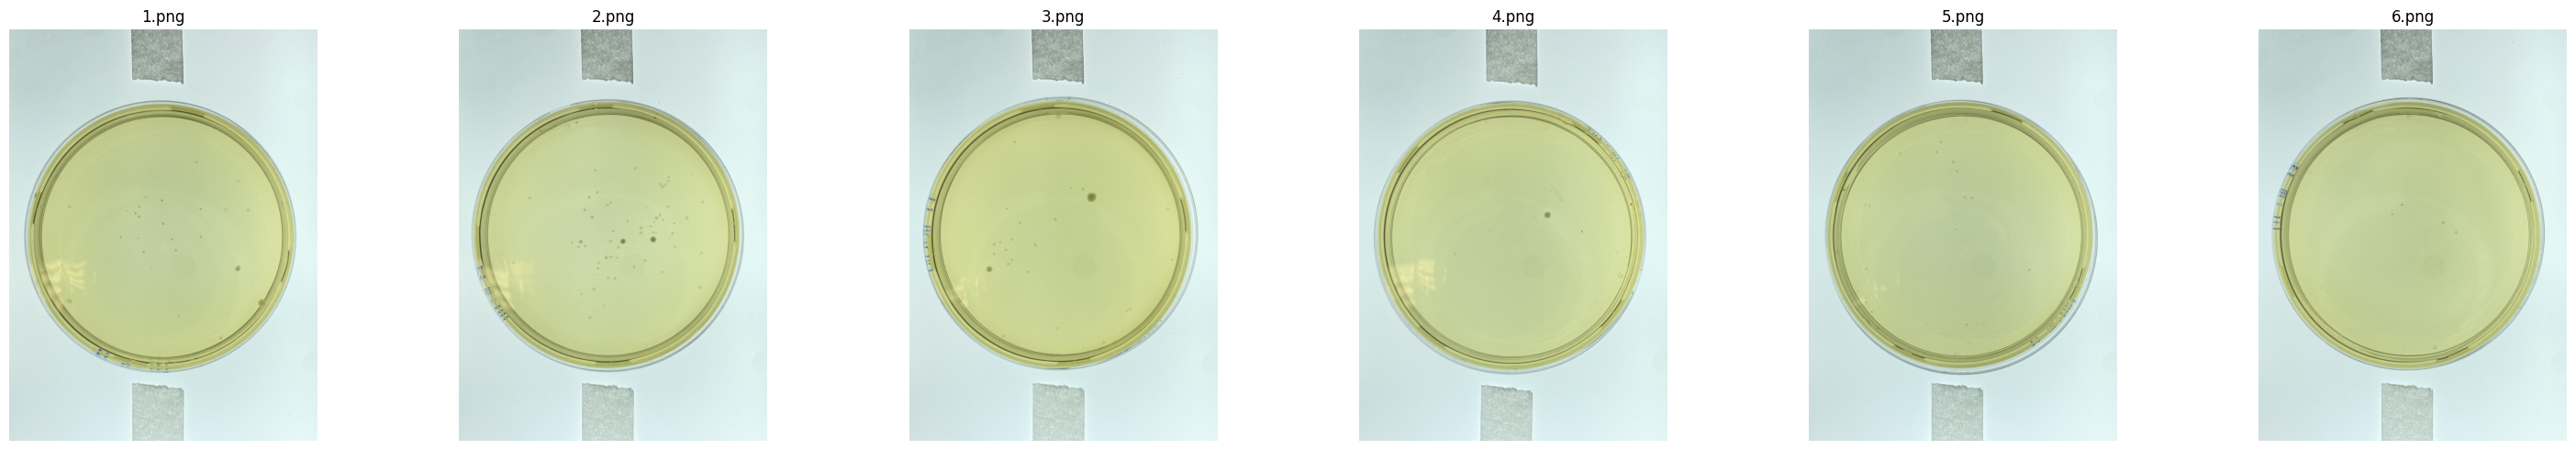

In [57]:
base_path = "/Users/laura/Documents/Unicamp/pattern-recognition-petri-dishes/notebooks/laura/data/preprocess/heic2png_R1_cnpem"

arquivos = sorted(
    [f for f in os.listdir(base_path) if f.endswith(".png")],
    key=lambda x: int(os.path.splitext(x)[0])
)

n = len(arquivos)
fig, axs = plt.subplots(1, n, figsize=(5 * n, 5))

all_imgs = []

for ax, nome in zip(axs, arquivos):
    full_path = os.path.join(base_path, nome)
    img = Image.open(full_path)
    all_imgs.append(img)
    ax.imshow(img)
    ax.set_title(nome)
    ax.axis('off')

plt.tight_layout()
plt.show()

---

## Etapa 3 — Análise dos Histogramas RGB (Imagens Originais)

Para entender como as intensidades de cor se distribuem nas imagens, calculamos o histograma separado para cada canal (R, G, B).

O histograma mostra a frequência de cada nível de intensidade (0 a 255) dentro do canal. Analisá-lo permite:

- Identificar qual canal oferece maior contraste entre colônias e fundo.
- Detectar dominâncias de cor causadas pela iluminação do equipamento.
- Observar a presença de picos bimodais, que indicam separabilidade entre fundo e objeto de interesse.

A normalização pelo `y_max` de cada imagem padroniza a escala vertical, tornando a comparação entre imagens mais justa.


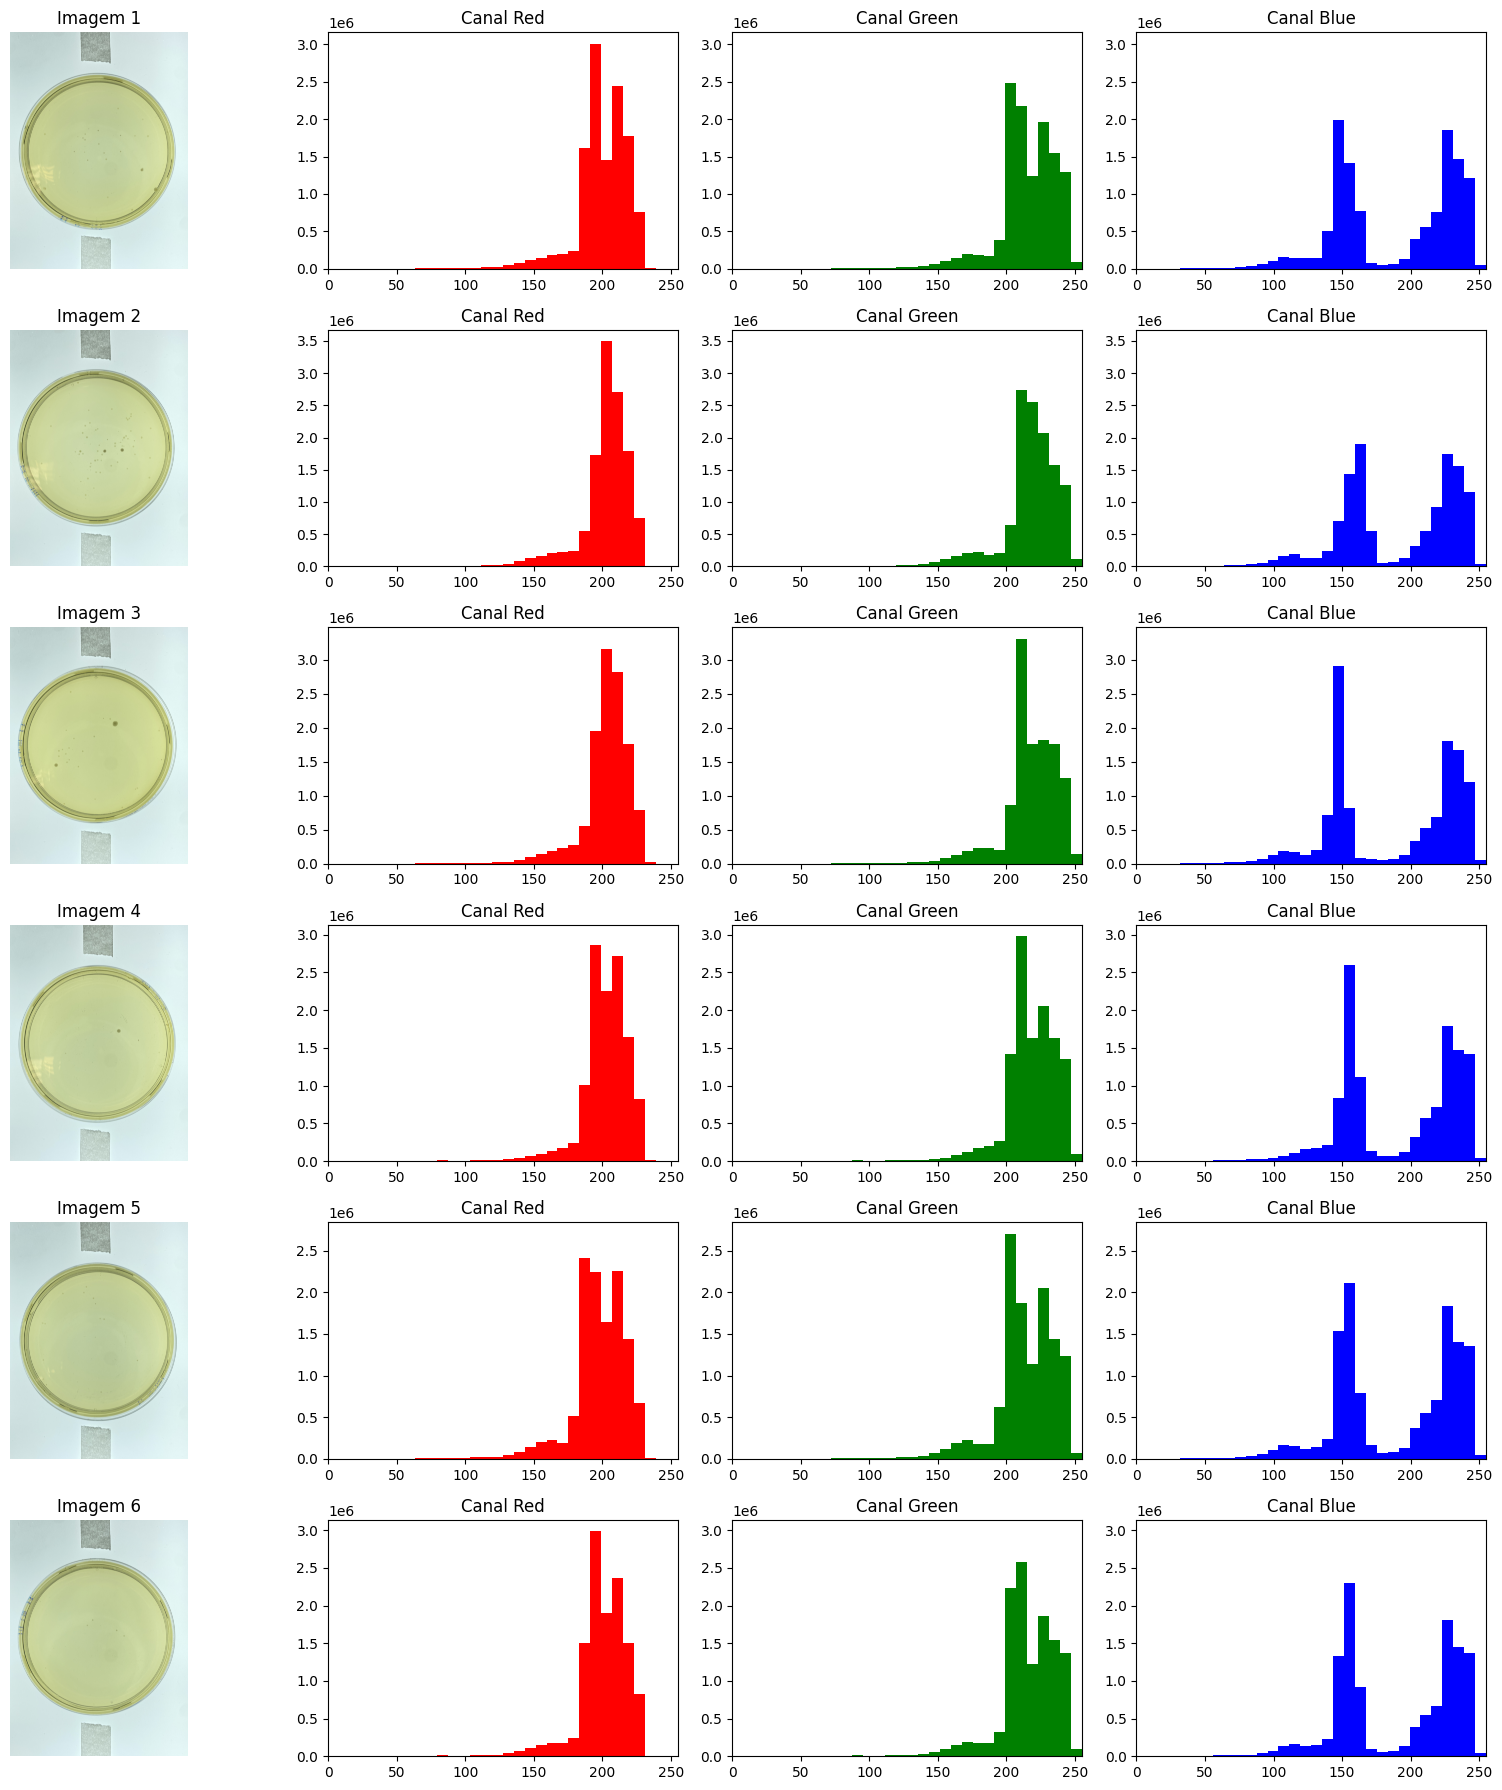

In [58]:
nbins = 32
cores = ['red', 'green', 'blue']
n = len(all_imgs)
fig, axs = plt.subplots(n, 4, figsize=(16, 3 * n))

for i, img_pil in enumerate(all_imgs):
    img = np.array(img_pil)
    
    axs[i, 0].imshow(img)
    axs[i, 0].set_title(f"Imagem {i+1}")
    axs[i, 0].axis('off')

    y_max = 0
    for b in range(3):
        hist_temp, _ = np.histogram(img[:, :, b], bins=nbins, range=(0, 255))
        y_max = max(y_max, hist_temp.max())

    for banda in range(3):
        canal = img[:, :, banda]
        h, bin_edges = np.histogram(canal, bins=nbins, range=(0, 255))
        
        ax_hist = axs[i, banda + 1]
        plt.sca(ax_hist)
        
        plota_hist(h, cores[banda], nbins, bin_edges)
        
        ax_hist.set_xlim(0, 255)
        ax_hist.set_ylim(0, y_max * 1.05)
        ax_hist.set_title(f"Canal {cores[banda].capitalize()}")

plt.tight_layout()
plt.show()

## Etapa 4 — Recorte da Placa com Hough Circles (ROI)

O fundo ao redor da placa de Petri introduz **ruído desnecessário** na análise. Para focar apenas na região de interesse (ROI), recortamos a placa de forma circular usando o **algoritmo de Hough Circles** do OpenCV.

O algoritmo detecta círculos em uma imagem em escala de cinza com base no gradiente de intensidade. Os parâmetros principais são:

| Parâmetro | Significado |
|---|---|
| `dp` | Resolução do acumulador igual à da imagem original |
| `minDist` | Distância mínima entre centros de círculos distintos |
| `param1` | Limiar superior do detector de bordas Canny interno |
| `param2` | Sensibilidade do acumulador (menor = mais detecções, mais falsos positivos) |
| `minRadius / maxRadius` | Faixa de raios aceita |

Após detectar o círculo dominante (a borda da placa), cria-se uma máscara binária com aquela forma e a aplicamos à imagem original, zerando tudo fora da placa. Os arquivos são salvos como `1_cropped.png`, `2_cropped.png`, ...

Foi adicionado um `time.time()` para medir o tempo de processamento total — útil para identificar gargalos na pipeline caso o número de imagens aumente.


In [59]:
base_path = "/Users/laura/Documents/Unicamp/pattern-recognition-petri-dishes/notebooks/laura/data/preprocess/heic2png_R1_cnpem"
output_path = "/Users/laura/Documents/Unicamp/pattern-recognition-petri-dishes/notebooks/laura/data/preprocess/crop_circles_R1"

if not os.path.exists(output_path):
    os.makedirs(output_path)

start_time = time.time()

arquivos = sorted(
    [f for f in os.listdir(base_path) if f.endswith(".png")],
    key=lambda x: int(os.path.splitext(x)[0])
)

for img_name in arquivos:
    full_path = os.path.join(base_path, img_name)
    print(f"Processando: {img_name}...")

    img = cv2.imread(full_path)
    if img is None:
        print(f"Erro ao carregar {img_name}")
        continue

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    gray_blurred = cv2.medianBlur(gray, 5)

    circles = cv2.HoughCircles(
        gray_blurred,
        cv2.HOUGH_GRADIENT,
        dp=1,
        minDist=100,
        param1=50,
        param2=30,
        minRadius=10,
        maxRadius=0
    )

    if circles is not None:
        circles = np.uint16(np.around(circles))
        c = circles[0, 0]
        centro_x, centro_y, raio = c[0], c[1], c[2]

        mask = np.zeros_like(gray)
        cv2.circle(mask, (centro_x, centro_y), raio, 255, -1)

        final_img = np.zeros_like(img)
        final_img[mask == 255] = img[mask == 255]

        save_name = f"{os.path.splitext(img_name)[0]}_cropped.png"
        cv2.imwrite(os.path.join(output_path, save_name), final_img)
        print(f"   > Salvo: {save_name} (Raio detectado: {raio})")
    else:
        print(f"   > Nenhum círculo detectado em {img_name}.")

end_time = time.time()
print(f"Tempo total: {end_time - start_time:.2f} segundos")

Processando: 1.png...
   > Salvo: 1_cropped.png (Raio detectado: 1330)
Processando: 2.png...
   > Salvo: 2_cropped.png (Raio detectado: 1279)
Processando: 3.png...
   > Salvo: 3_cropped.png (Raio detectado: 1277)
Processando: 4.png...
   > Salvo: 4_cropped.png (Raio detectado: 1332)
Processando: 5.png...
   > Salvo: 5_cropped.png (Raio detectado: 1279)
Processando: 6.png...
   > Salvo: 6_cropped.png (Raio detectado: 1276)
Tempo total: 858.55 segundos


---

## Etapa 5 — Visualização das Imagens Recortadas

Após o recorte circular, carregamos as imagens já processadas e as exibimos lado a lado para confirmar visualmente que o recorte foi bem-sucedido — a placa deve estar centralizada e o fundo externo completamente preto.


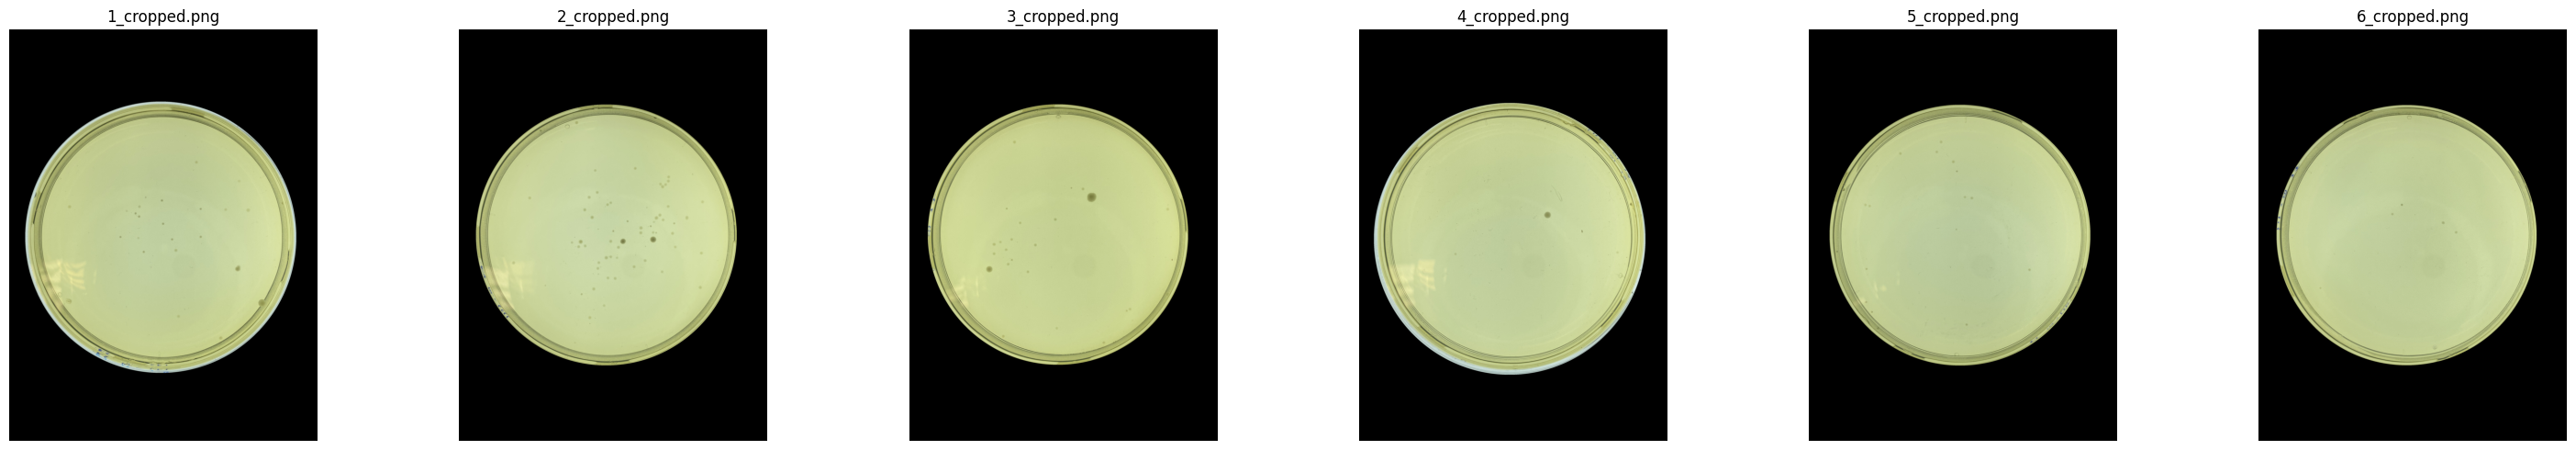

In [60]:
base_path = "/Users/laura/Documents/Unicamp/pattern-recognition-petri-dishes/notebooks/laura/data/preprocess/crop_circles_R1"

arquivos = sorted(
    [f for f in os.listdir(base_path) if f.endswith(".png")],
    key=lambda x: int(x.replace("_cropped", "").replace(".png", ""))
)

n = len(arquivos)
fig, axs = plt.subplots(1, n, figsize=(5 * n, 5))

all_imgs = []

for ax, nome in zip(axs, arquivos):
    full_path = os.path.join(base_path, nome)
    img = Image.open(full_path)
    all_imgs.append(img)
    ax.imshow(img)
    ax.set_title(nome)
    ax.axis('off')

plt.tight_layout()
plt.show()

### Análise

As imagens não estão igualmente recortadas, isso pode ser observado tanto pelo output de raio detectado quanto pela visualização das imagens (observe as fotos 4 e 6). Isso pode ser devido ao ajuste de parâmetros do Hough Circles, que não é necessariamente igual para todas as imagens. Isso levanta um ponto importante: **a etapa de captura das imagens deve ser uniforme**, mantendo reprodutibilidade entre todas as amostras.


---

## Etapa 6 — Histogramas das Imagens Recortadas

Repetimos a análise de histogramas, agora sobre as imagens com fundo preto.

Com o fundo original (variado e colorido), os histogramas exibiam ruído de fundo — pixels do ambiente que distorciam a distribuição. Com o fundo preto (intensidade 0), a distribuição fica mais limpa:

- O pico em 0 representa o fundo mascarado.
- Os demais picos representam as colônias e a superfície da placa.

Essa clareza facilita a escolha do limiar de segmentação ao identificar o vale entre o pico do fundo (0) e o pico das colônias.


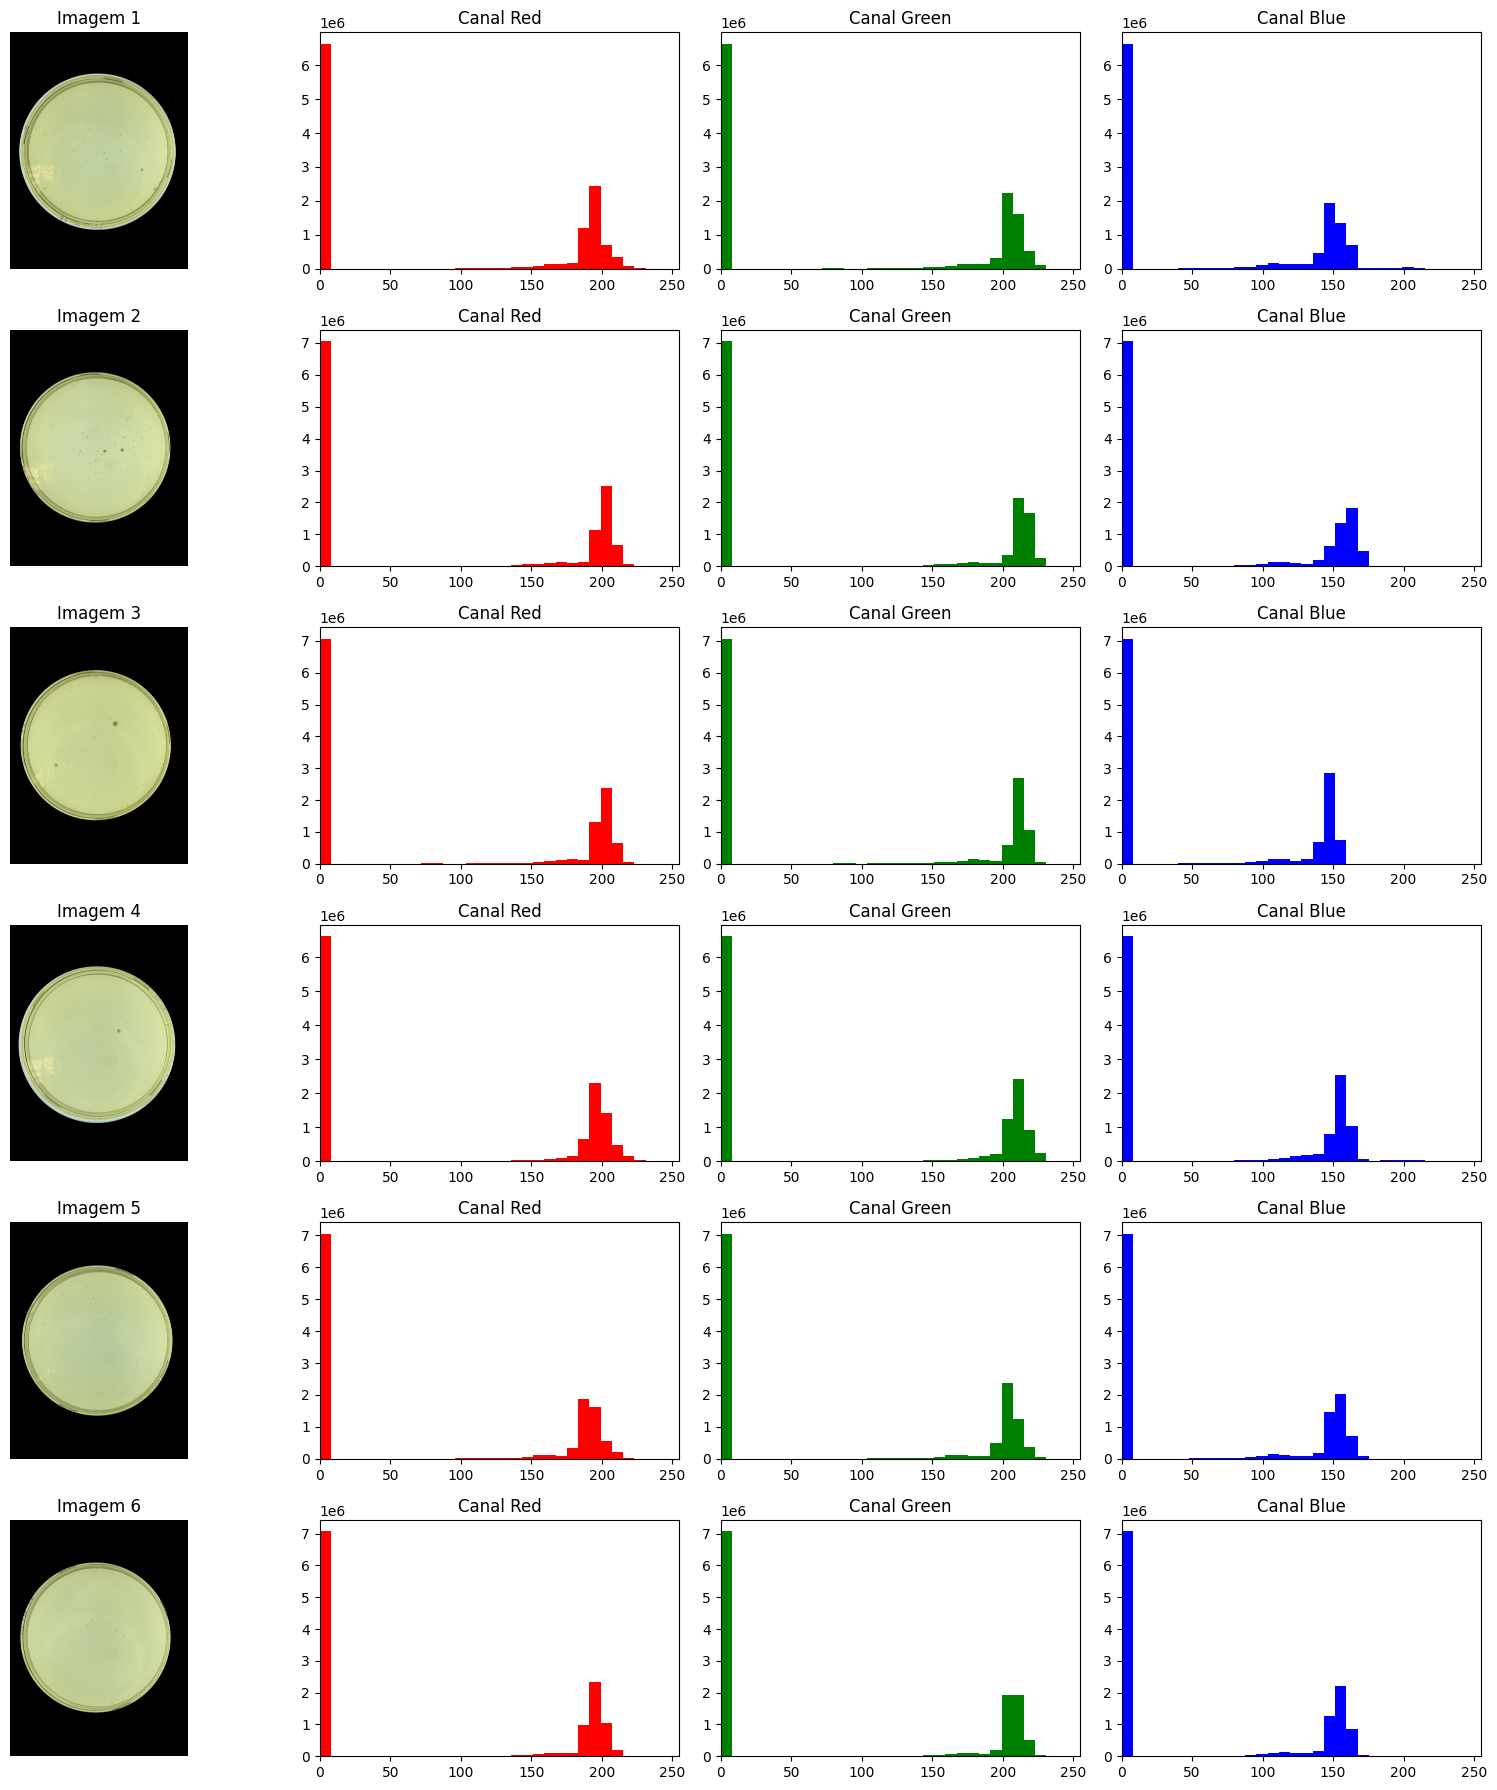

In [61]:
nbins = 32
cores = ['red', 'green', 'blue']
n = len(all_imgs)
fig, axs = plt.subplots(n, 4, figsize=(16, 3 * n))

for i, img_pil in enumerate(all_imgs):
    img = np.array(img_pil)
    
    axs[i, 0].imshow(img)
    axs[i, 0].set_title(f"Imagem {i+1}")
    axs[i, 0].axis('off')

    y_max = 0
    for b in range(3):
        hist_temp, _ = np.histogram(img[:, :, b], bins=nbins, range=(0, 255))
        y_max = max(y_max, hist_temp.max())

    for banda in range(3):
        canal = img[:, :, banda]
        h, bin_edges = np.histogram(canal, bins=nbins, range=(0, 255))
        
        ax_hist = axs[i, banda + 1]
        plt.sca(ax_hist)
        
        plota_hist(h, cores[banda], nbins, bin_edges)
        
        ax_hist.set_xlim(0, 255)
        ax_hist.set_ylim(0, y_max * 1.05)
        ax_hist.set_title(f"Canal {cores[banda].capitalize()}")

plt.tight_layout()
plt.show()

---

## Etapa 7 — Separação dos Canais e Limiarização Manual

### 7.1 — Visualização por canal

Carregamos uma imagem específica (`1_cropped.png`) e exibimos seus três canais separadamente em escala de cinza. Isso confirma visualmente qual canal melhor separa as colônias do fundo.


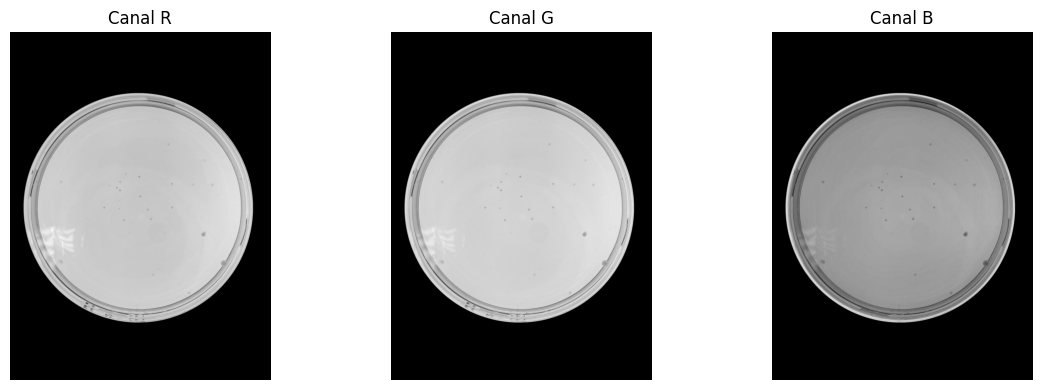

In [62]:
f = mpimg.imread("/Users/laura/Documents/Unicamp/pattern-recognition-petri-dishes/notebooks/laura/data/preprocess/crop_circles_R1/1_cropped.png")

if f.dtype == np.float32 or f.dtype == np.float64:
    f = (f * 255).astype('uint8')

fig, axs = plt.subplots(1, 3, figsize=(12, 4))
titulos = ['Canal R', 'Canal G', 'Canal B']

for i in range(3):
    axs[i].imshow(f[:, :, i], cmap='gray')
    axs[i].set_title(titulos[i])
    axs[i].axis('off')

plt.tight_layout()
plt.show()

### 7.2 — Limiarização por tabela de mapeamento (LUT)

Aplicamos uma limiarização manual com `threshold = 120` no **Canal B**. A técnica usa uma Look-Up Table (LUT): um vetor de 256 posições que mapeia cada intensidade de entrada para 0 ou 255.

- Pixels com intensidade **menor que 120** → brancos (255): regiões de colônias/luz.
- Pixels com intensidade **maior ou igual a 120** → pretos (0): fundo escuro.

O resultado é uma máscara binária destacando as colônias como regiões brancas.


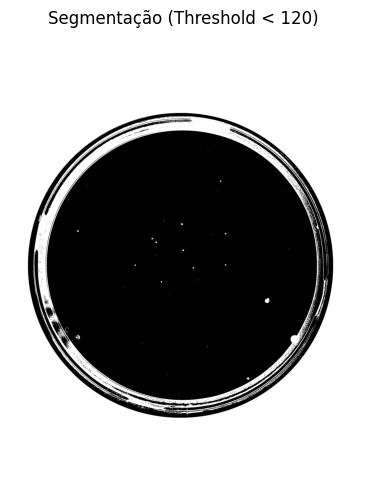

In [63]:
threshold = 120
T = np.arange(256).astype('uint8')

T_seg = np.where(T < threshold, 255, 0).astype('uint8')

f_seg = T_seg[f[:, :, 2]]

plt.figure(figsize=(6, 6))
plt.imshow(f_seg, cmap='gray')
plt.title(f'Segmentação (Threshold < {threshold})')
plt.axis('off')
plt.show()

---

## Etapa 8 — Contagem por Componentes Conectados

Com a máscara binária da etapa anterior, aplicamos a contagem usando **Connected Components** (`cv2.connectedComponentsWithStats`).

1. **Máscara circular interna** — uma nova máscara circular mais conservadora (raio = 35% da menor dimensão) é criada para evitar artefatos nas bordas do recorte.
2. **Abertura morfológica** (`MORPH_OPEN`) — remove pequenos ruídos isolados sem afetar as colônias maiores.
3. **Rotulagem de componentes** — cada grupo de pixels brancos conectados recebe um rótulo único (inteiro).
4. **Filtro por área mínima** — componentes com área menor que 15 pixels são descartados como ruído.

O resultado é exibido em duas vistas: a área de análise delimitada pelo círculo vermelho e os componentes coloridos por rótulo.


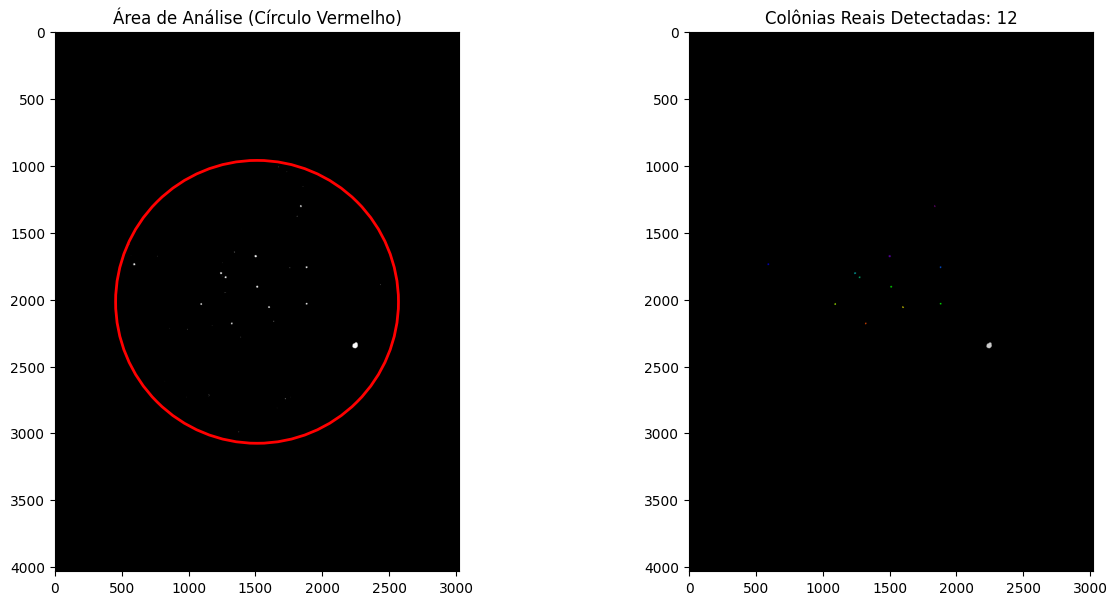

Filtro aplicado! Contagem final: 12 objetos com área > 15 pixels.


In [ ]:
h, w = f_seg.shape
mask_circ = np.zeros((h, w), dtype=np.uint8)
centro = (w // 2, h // 2)
raio_seguro = int(min(w, h) * 0.35)
cv2.circle(mask_circ, centro, raio_seguro, 255, -1)

f_seg_focada = cv2.bitwise_and(f_seg, f_seg, mask=mask_circ)

kernel = np.ones((3,3), np.uint8)
opening = cv2.morphologyEx(f_seg_focada, cv2.MORPH_OPEN, kernel, iterations=1)

num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(opening)

area_minima = 15

contagem_real = 0
labels_filtrados = np.zeros_like(labels)

for i in range(1, num_labels):
    area = stats[i, cv2.CC_STAT_AREA]
    if area >= area_minima:
        contagem_real += 1
        labels_filtrados[labels == i] = i

plt.figure(figsize=(15, 7))

plt.subplot(1, 2, 1)
plt.imshow(f_seg_focada, cmap='gray')
circ_plot = plt.Circle(centro, raio_seguro, color='red', fill=False, lw=2)
plt.gca().add_patch(circ_plot)
plt.title("Área de Análise (Círculo Vermelho)")

plt.subplot(1, 2, 2)
plt.imshow(labels_filtrados, cmap='nipy_spectral')
plt.title(f"Colônias Reais Detectadas: {contagem_real}")
plt.show()

print(f"Filtro aplicado! Contagem final: {contagem_real} objetos com área > {area_minima} pixels.")

---

## Etapa 9 — Comparação de Estratégias de Limiarização

Para avaliar qual método de segmentação funciona melhor, a função `thresholds()` compara três abordagens em uma mesma imagem:

| Método | Descrição |
|---|---|
| **Otsu** | Calcula automaticamente o limiar ótimo que maximiza a variância entre fundo e objeto.  clara. |
| **Adaptativo Gaussiano** | Calcula um limiar diferente para cada região local da imagem, compensando variações de iluminação. |
| **Top-Hat Morfológico** | Realça estruturas pequenas e brilhantes sobre um fundo uniforme. |

Todos os métodos são aplicados sobre o Canal B após suavização com mediana, e o resultado é restrito à máscara circular da placa.


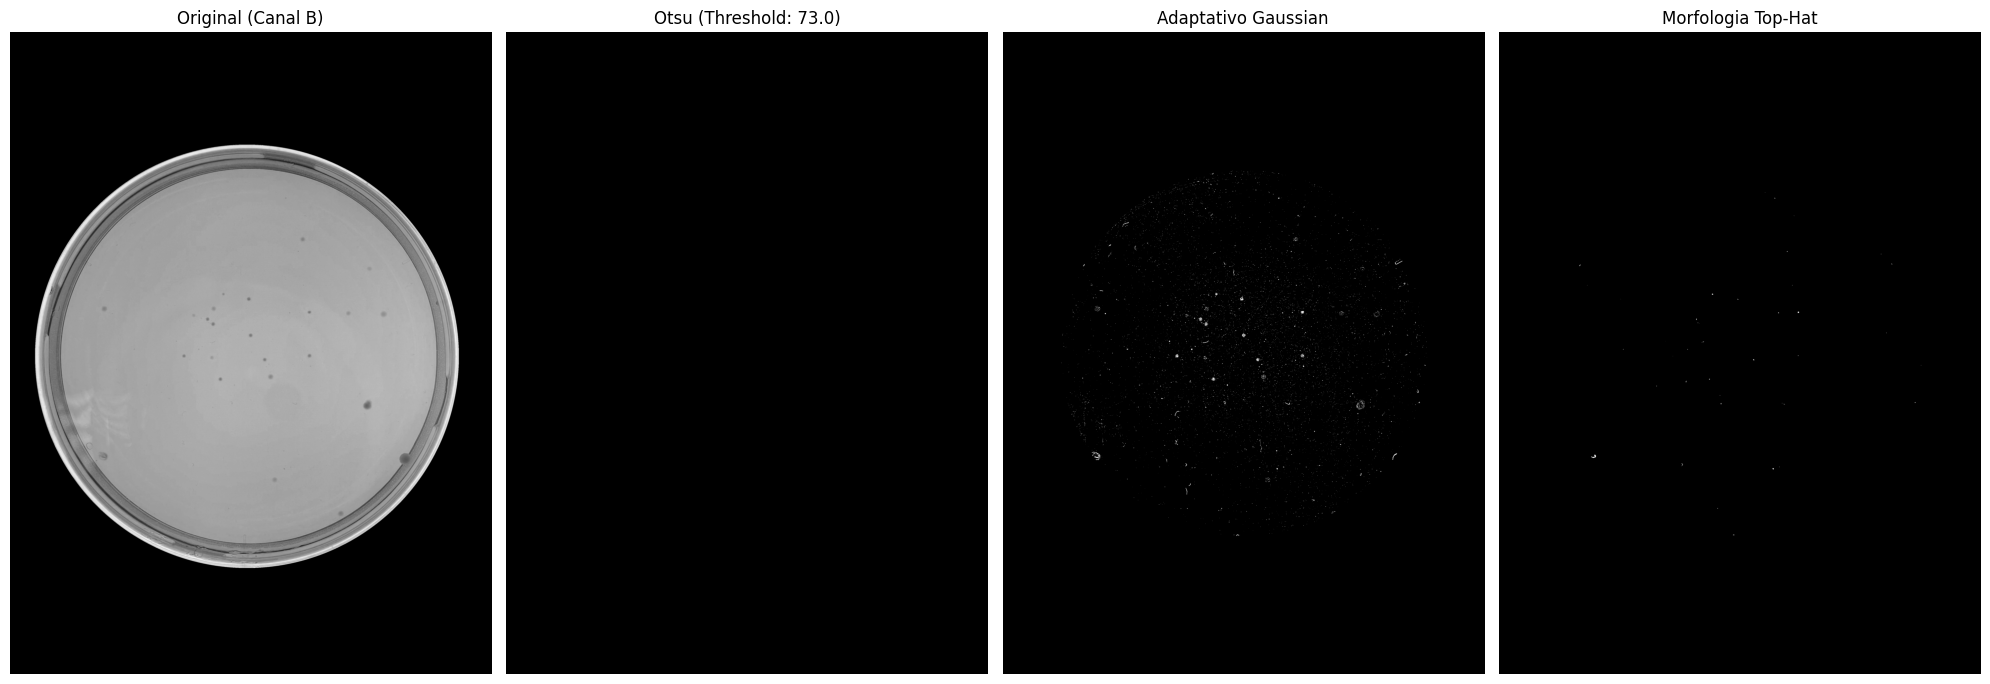

In [65]:
def thresholds(caminho_img):
    img = cv2.imread(caminho_img)
    if img is None:
        print("Erro ao carregar a imagem.")
        return
    
    canal_b = img[:, :, 0]  # Canal B no OpenCV (BGR)
    canal_b = cv2.medianBlur(canal_b, 5)

    h, w = canal_b.shape
    mask_circ = np.zeros((h, w), dtype=np.uint8)
    cv2.circle(mask_circ, (w//2, h//2), int(min(w, h)*0.38), 255, -1)

    # Otsu
    val_otsu, bin_otsu = cv2.threshold(canal_b, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    res_otsu = cv2.bitwise_and(bin_otsu, bin_otsu, mask=mask_circ)

    # Adaptativo Gaussiano
    bin_adap = cv2.adaptiveThreshold(canal_b, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                     cv2.THRESH_BINARY_INV, 11, 2)
    res_adap = cv2.bitwise_and(bin_adap, bin_adap, mask=mask_circ)

    # Top-Hat Morfológico
    inv_b = cv2.bitwise_not(canal_b)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (15, 15))
    tophat = cv2.morphologyEx(inv_b, cv2.MORPH_TOPHAT, kernel)
    _, bin_tophat = cv2.threshold(tophat, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    res_tophat = cv2.bitwise_and(bin_tophat, bin_tophat, mask=mask_circ)

    titulos = [f'Original (Canal B)', f'Otsu (Threshold: {val_otsu:.1f})',
               'Adaptativo Gaussian', 'Morfologia Top-Hat']
    imagens = [canal_b, res_otsu, res_adap, res_tophat]

    plt.figure(figsize=(20, 10))
    for i in range(4):
        plt.subplot(1, 4, i+1)
        plt.imshow(imagens[i], cmap='gray')
        plt.title(titulos[i])
        plt.axis('off')
    plt.tight_layout()
    plt.show()

caminho = "/Users/laura/Documents/Unicamp/pattern-recognition-petri-dishes/notebooks/laura/data/preprocess/crop_circles_R1/1_cropped.png"
thresholds(caminho)


## Etapa 10 — Pipeline com Subtração de Fundo + Otsu


A limiarização direta sobre o Canal B sofre com **variações de iluminação** dentro da própria placa — o centro pode ser mais brilhante que as bordas, fazendo com que um único limiar global falhe em algumas regiões.

A solução é a **subtração de fundo estimado**:

1. **Suavização inicial** — `medianBlur(5)` remove ruídos pontuais.
2. **Estimativa do fundo** — um `GaussianBlur` com kernel muito grande (151×151) cria uma versão da imagem que representa apenas a variação lenta de iluminação, sem os detalhes das colônias.
3. **Subtração** — `absdiff(fundo, canal_b)` elimina o gradiente de luz e realça apenas as colônias.
4. **Normalização** — o resultado é normalizado para o intervalo [0, 255].
5. **Otsu sobre o diff** — com o fundo removido, a distribuição é bimodal e o Otsu funciona bem.
6. **Máscara circular** — restringe a detecção à área da placa.


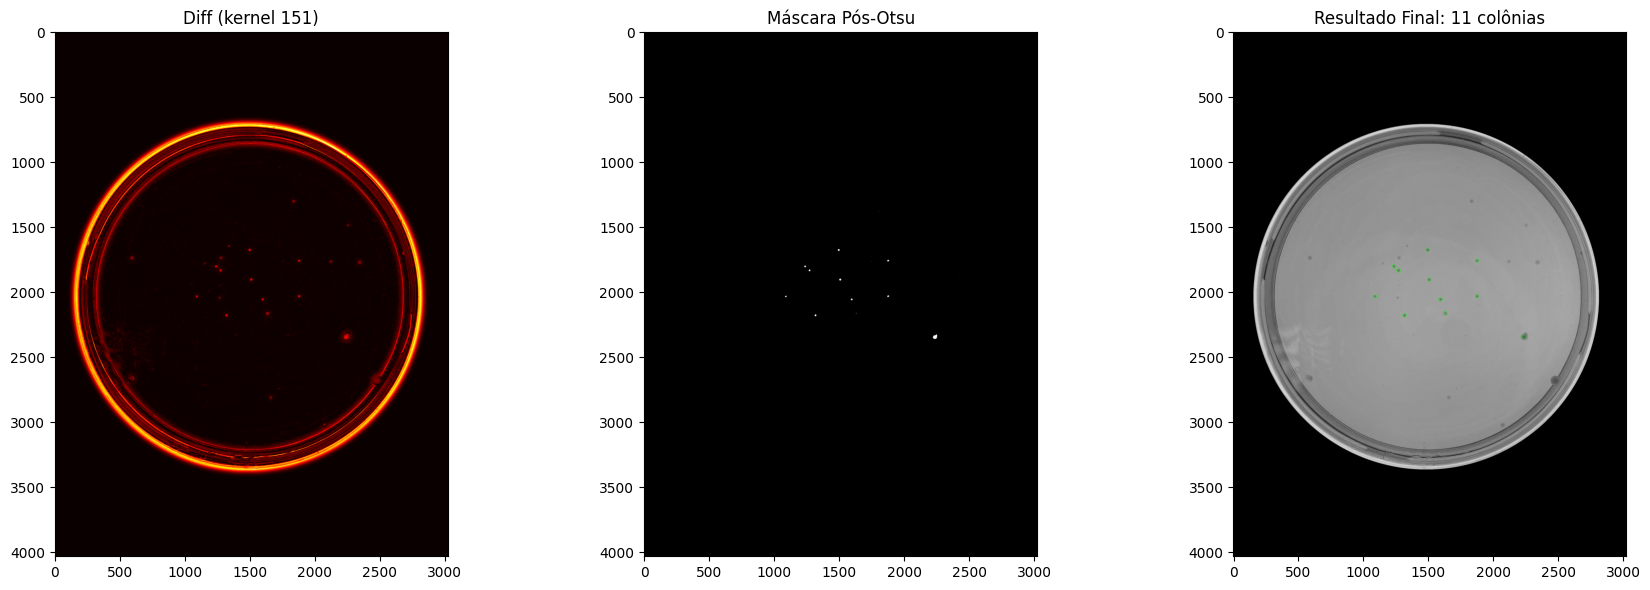

In [66]:
def diff_otsu(img_path, kernel_size=151, area_min=10, area_max=1000):
    img = cv2.imread(img_path)
    canal_b = img[:, :, 0]  # Canal B (BGR)
    
    canal_b = cv2.medianBlur(canal_b, 5)
    fundo = cv2.GaussianBlur(canal_b, (kernel_size, kernel_size), 0)
    
    diff = cv2.absdiff(fundo, canal_b)
    diff = cv2.normalize(diff, None, 0, 255, cv2.NORM_MINMAX)
    
    val_otsu, thresh = cv2.threshold(diff, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    
    h, w = thresh.shape
    mask_circ = np.zeros((h, w), dtype=np.uint8)
    cv2.circle(mask_circ, (w//2, h//2), int(min(w, h)*0.36), 255, -1)
    f_seg = cv2.bitwise_and(thresh, thresh, mask=mask_circ)
    
    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(f_seg)
    
    contagem = 0
    viz_final = cv2.cvtColor(canal_b, cv2.COLOR_GRAY2BGR)
    
    for i in range(1, num_labels):
        area = stats[i, cv2.CC_STAT_AREA]
        if area_min <= area <= area_max:
            contagem += 1
            cx, cy = centroids[i]
            cv2.circle(viz_final, (int(cx), int(cy)), 15, (0, 255, 0), 2)

    plt.figure(figsize=(18, 6))
    plt.subplot(1, 3, 1); plt.imshow(diff, cmap='hot'); plt.title(f"Diff (kernel {kernel_size})")
    plt.subplot(1, 3, 2); plt.imshow(f_seg, cmap='gray'); plt.title("Máscara Pós-Otsu")
    plt.subplot(1, 3, 3); plt.imshow(cv2.cvtColor(viz_final, cv2.COLOR_BGR2RGB))
    plt.title(f"Resultado Final: {contagem} colônias")
    plt.tight_layout()
    plt.show()

diff_otsu("/Users/laura/Documents/Unicamp/pattern-recognition-petri-dishes/notebooks/laura/data/preprocess/crop_circles_R1/1_cropped.png", kernel_size=151, area_min=10)

### Ajuste do kernel de estimativa de fundo

Testamos um kernel menor **(71×71)** — isso torna a estimativa de fundo mais responsiva a variações locais, mas pode começar a capturar algumas colônias no próprio fundo estimado.

O tamanho ideal deve ser **grande o suficiente para "pular sobre" as colônias** mas pequeno o suficiente para capturar a variação de iluminação real. Compare a máscara e a contagem entre as duas versões para decidir qual kernel generaliza melhor.


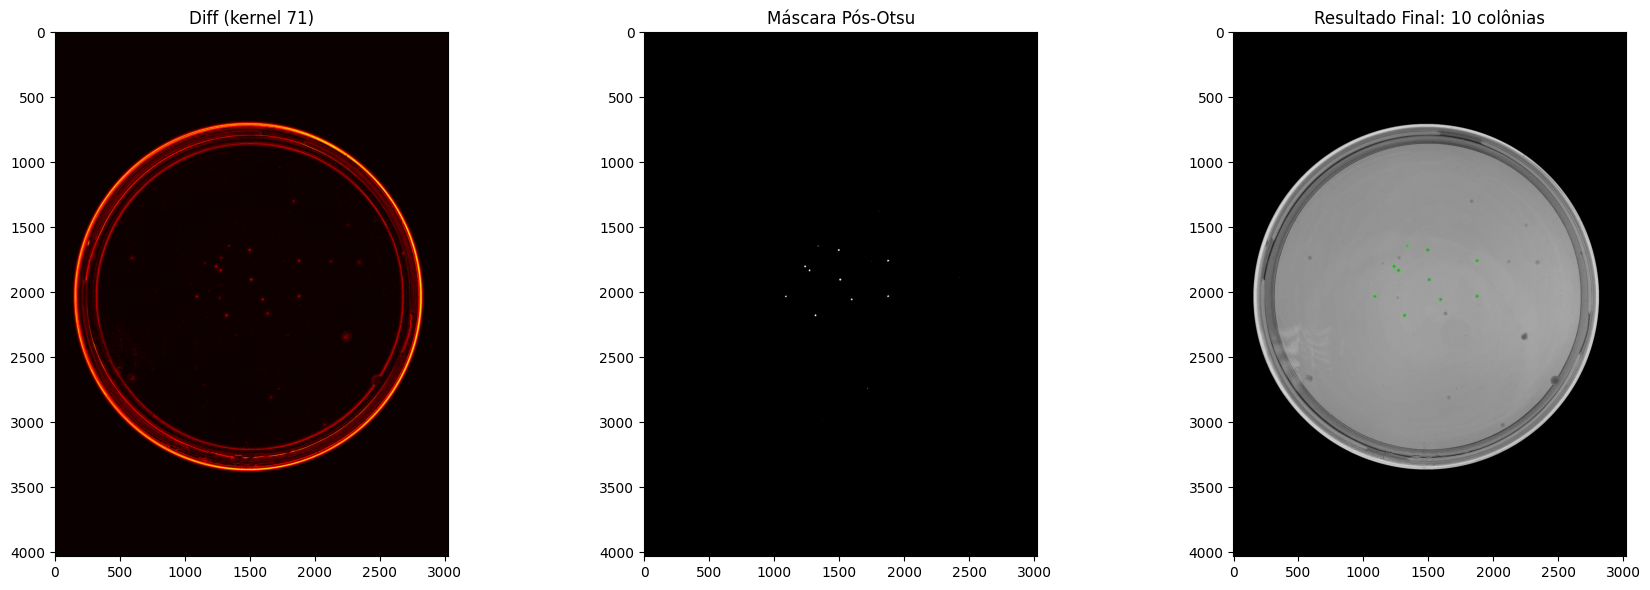

In [67]:
diff_otsu("/Users/laura/Documents/Unicamp/pattern-recognition-petri-dishes/notebooks/laura/data/preprocess/crop_circles_R1/1_cropped.png", kernel_size=71, area_min=35)

## Etapa 11 — Pipeline Final Integrada

A função `processamento_completo_colonias()` consolida todas as etapas anteriores em uma única chamada:

```
Imagem → Canal B → Suavização → Subtração de Fundo → Normalização
       → Otsu → Máscara Circular → Fechamento Morfológico
       → Connected Components → Filtragem por Área → Contagem + Visualização
```

- **`MORPH_CLOSE`** (fechamento) fecha buracos internos em colônias maiores — complementar ao `MORPH_OPEN`.
- Cada colônia detectada é **marcada com um círculo verde** e numerada para conferência visual.
- O limiar de área mínima (`area_minima = 20`) descarta artefatos.

### Saída

Três painéis: diff em mapa de calor, máscara binária pós-morfologia e imagem anotada com contagem.


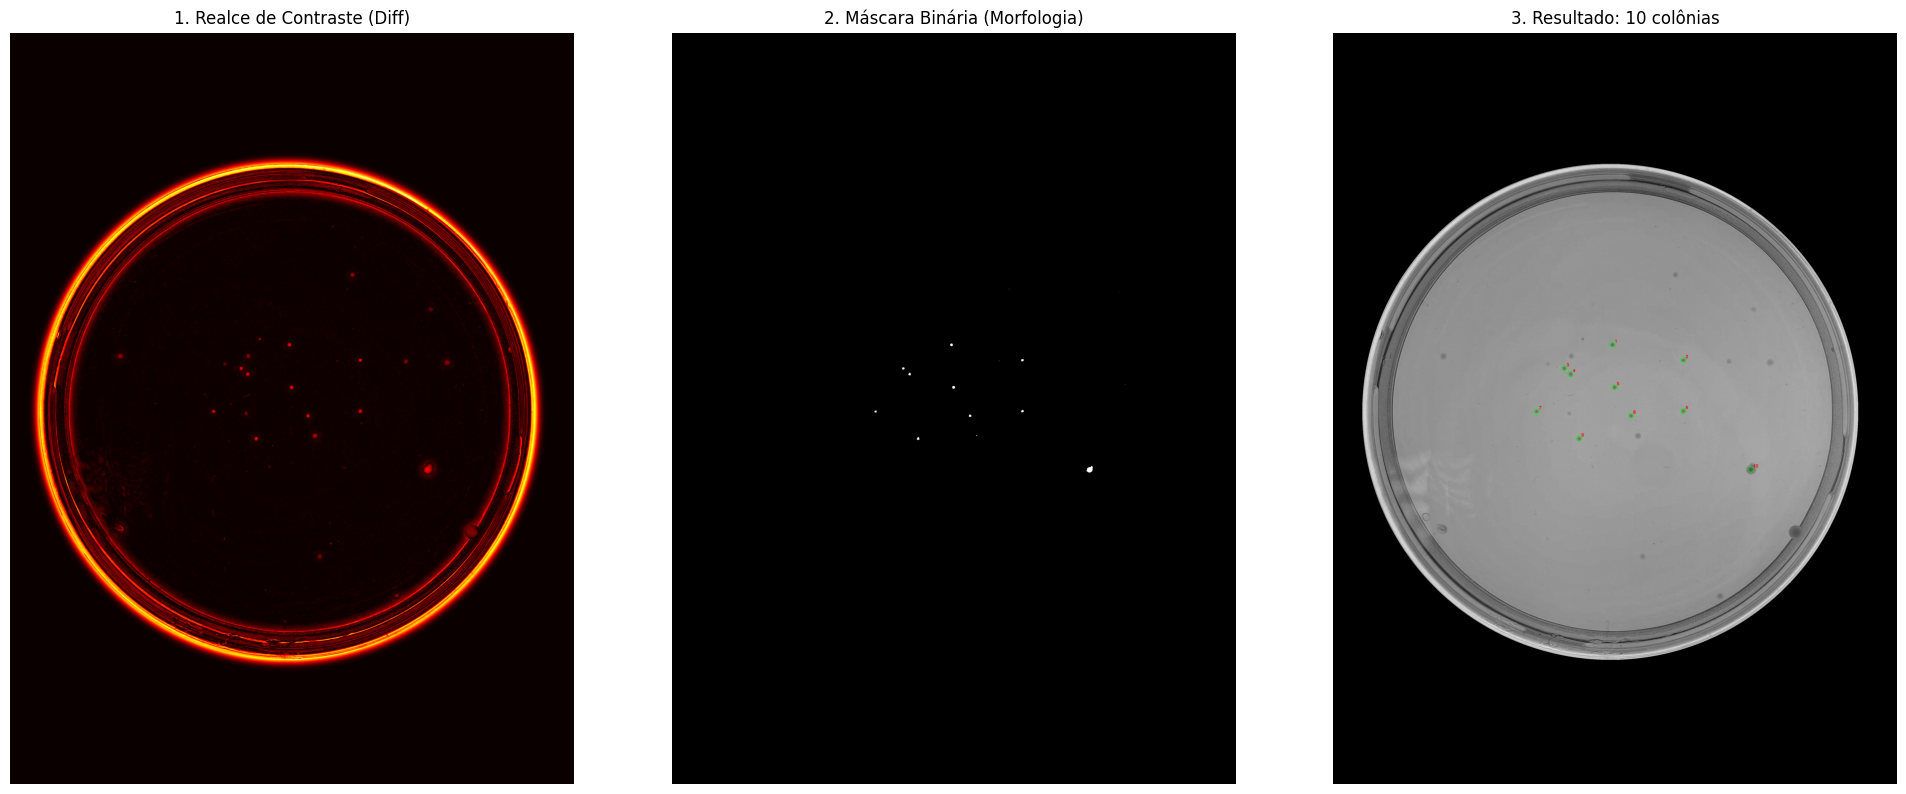

Total detectado: 10


In [68]:
def processamento_completo_colonias(img_path):
    img = cv2.imread(img_path)
    if img is None:
        print("Erro ao carregar a imagem.")
        return
    
    canal_b = img[:, :, 0]  # Canal B (BGR)
    
    suave = cv2.medianBlur(canal_b, 5)
    fundo = cv2.GaussianBlur(suave, (151, 151), 0)
    
    diff = cv2.absdiff(fundo, suave)
    diff = cv2.normalize(diff, None, 0, 255, cv2.NORM_MINMAX)
    
    _, thresh = cv2.threshold(diff, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    
    h, w = thresh.shape
    mask_circ = np.zeros((h, w), dtype=np.uint8)
    cv2.circle(mask_circ, (w//2, h//2), int(min(w, h)*0.36), 255, -1)
    f_focada = cv2.bitwise_and(thresh, thresh, mask=mask_circ)
    
    kernel = np.ones((5, 5), np.uint8)
    f_limpa = cv2.morphologyEx(f_focada, cv2.MORPH_CLOSE, kernel)
    
    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(f_limpa)
    
    contagem_real = 0
    viz_final = cv2.cvtColor(canal_b, cv2.COLOR_GRAY2RGB)
    area_minima = 20
    
    for i in range(1, num_labels):
        area = stats[i, cv2.CC_STAT_AREA]
        if area >= area_minima:
            contagem_real += 1
            cx, cy = centroids[i]
            cv2.circle(viz_final, (int(cx), int(cy)), 15, (0, 255, 0), 2)
            cv2.putText(viz_final, str(contagem_real), (int(cx) + 12, int(cy) - 12),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 0, 0), 2)

    plt.figure(figsize=(20, 8))
    plt.subplot(1, 3, 1); plt.imshow(diff, cmap='hot'); plt.title("1. Realce de Contraste (Diff)"); plt.axis('off')
    plt.subplot(1, 3, 2); plt.imshow(f_limpa, cmap='gray'); plt.title("2. Máscara Binária (Morfologia)"); plt.axis('off')
    plt.subplot(1, 3, 3); plt.imshow(viz_final); plt.title(f"3. Resultado: {contagem_real} colônias"); plt.axis('off')
    plt.tight_layout()
    plt.show()
    
    print(f"Total detectado: {contagem_real}")

caminho = "/Users/laura/Documents/Unicamp/pattern-recognition-petri-dishes/notebooks/laura/data/preprocess/crop_circles_R1/1_cropped.png"
processamento_completo_colonias(caminho)

---

## Etapa 12 — Comparação da Pipeline em Todas as Imagens

Aplicamos a pipeline completa em todas as imagens da pasta `crop_circles`, exibindo os resultados lado a lado para comparar o desempenho entre amostras.

Para cada imagem são mostrados três painéis: realce de contraste (diff), máscara binária e imagem anotada com a contagem final. Ao final, uma tabela resume a contagem de cada imagem.


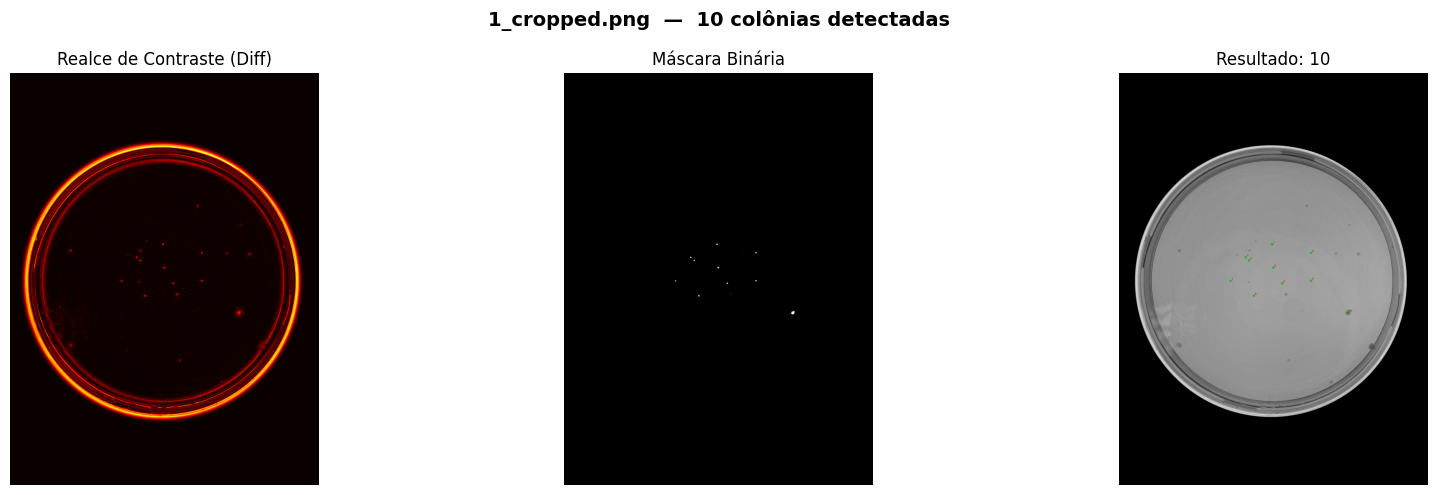

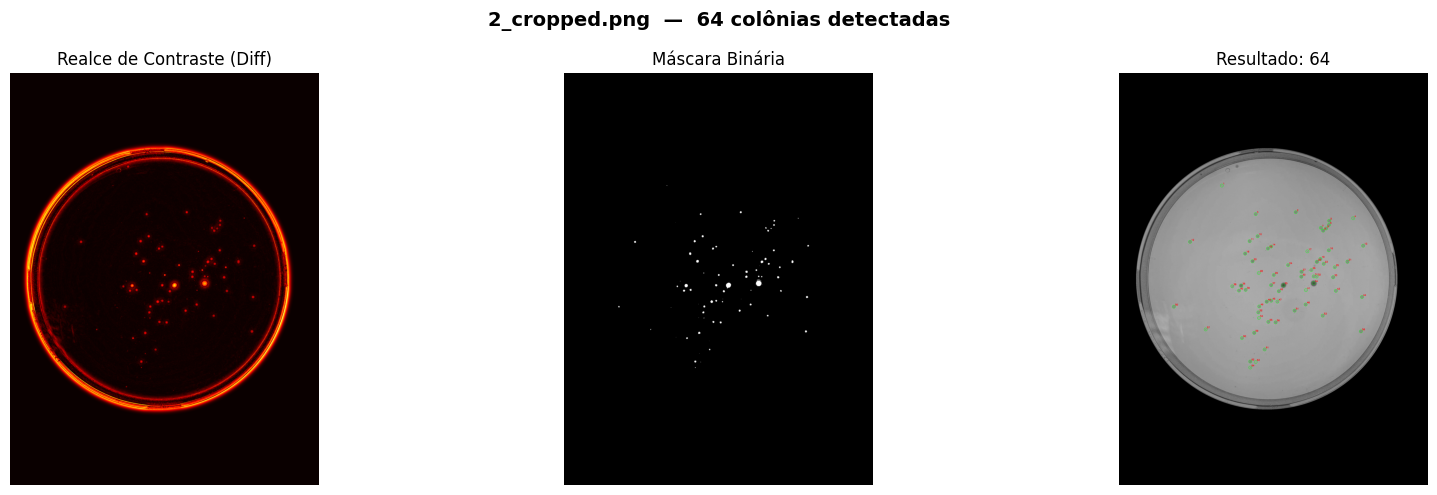

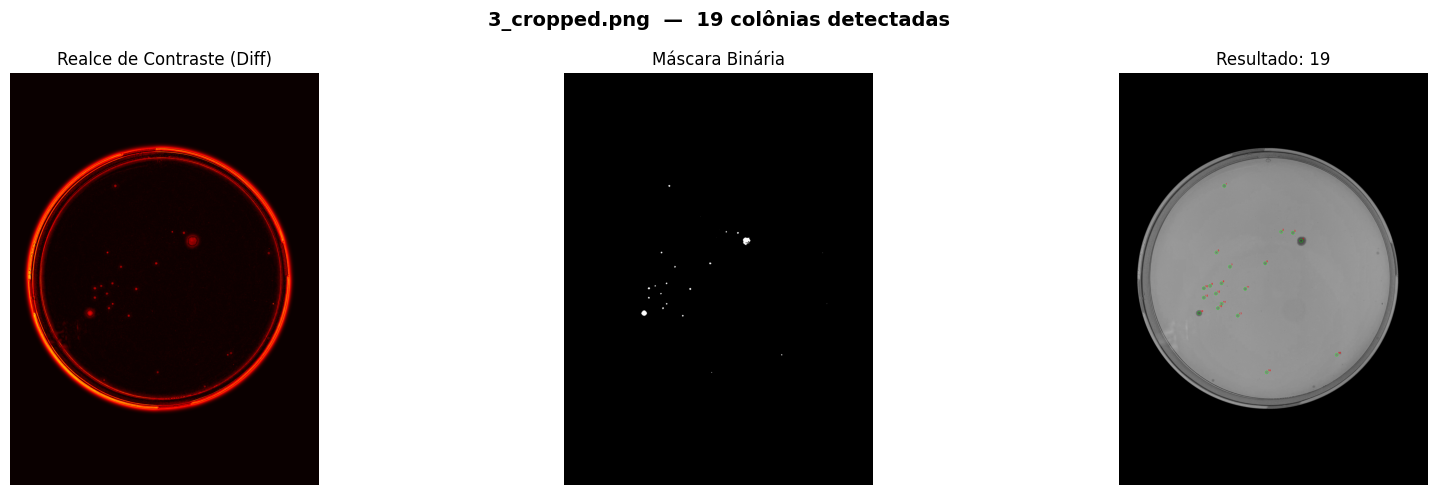

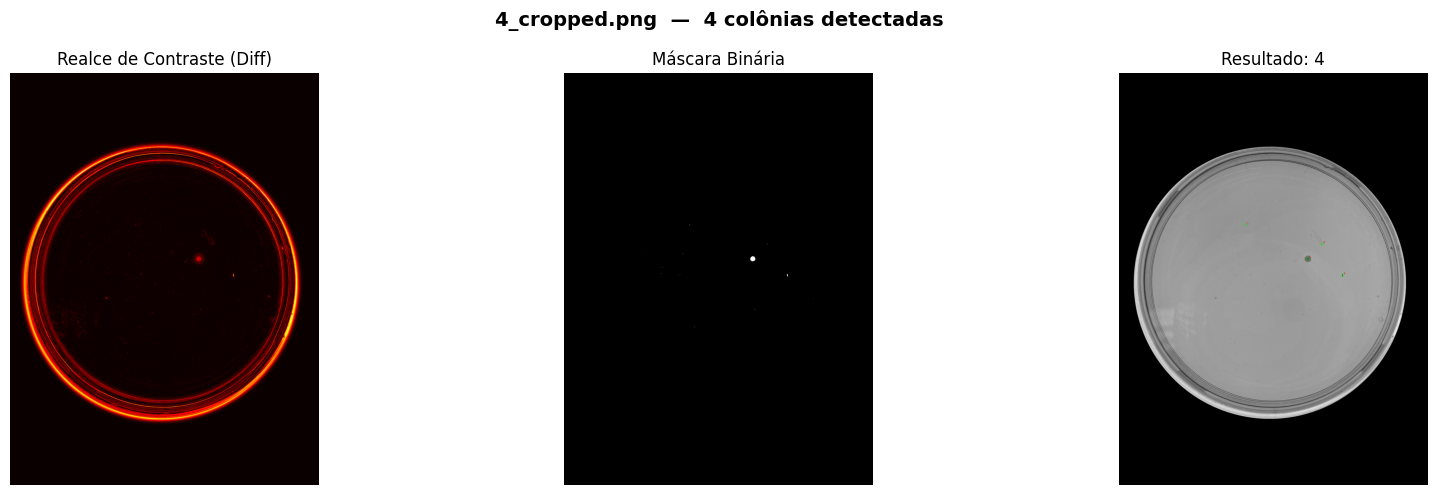

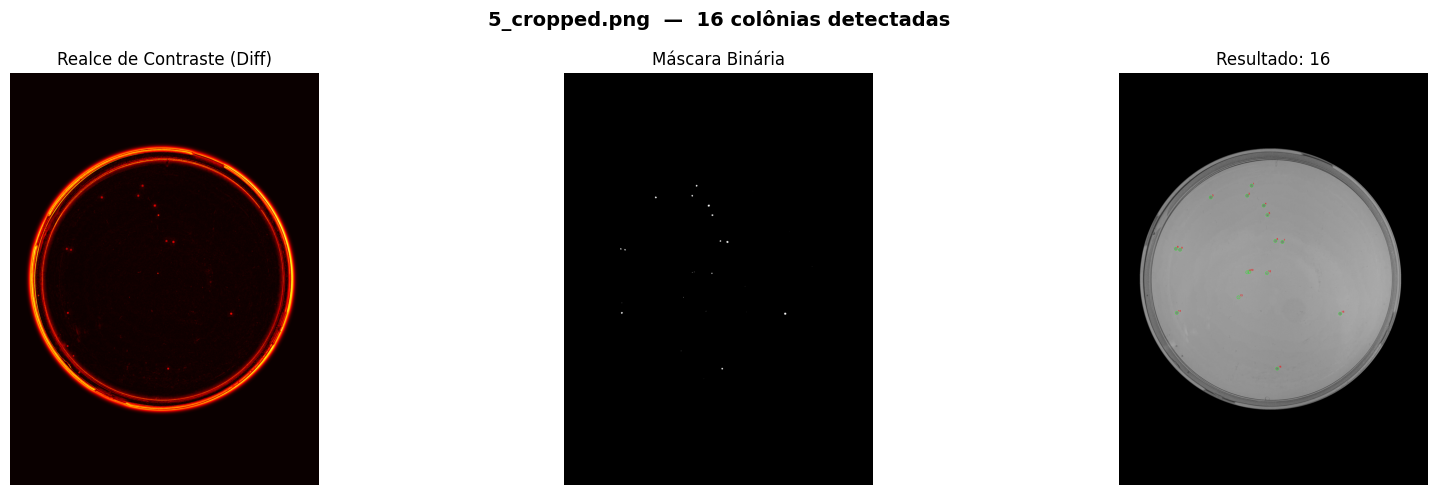

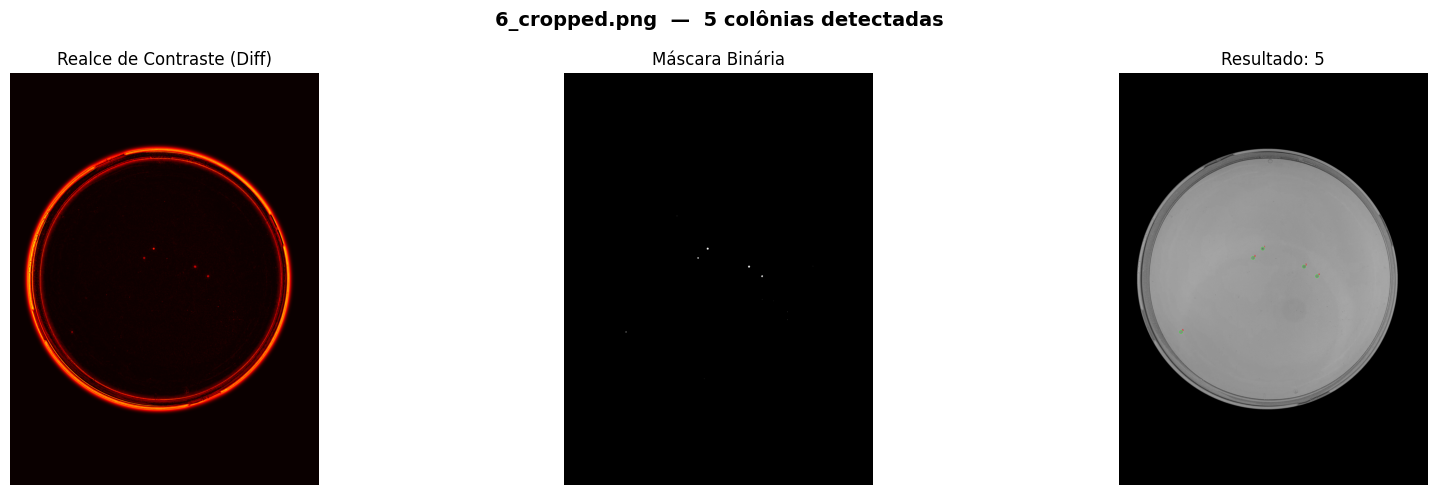

In [69]:
crop_path = "/Users/laura/Documents/Unicamp/pattern-recognition-petri-dishes/notebooks/laura/data/preprocess/crop_circles_R1"

arquivos_crop = sorted(
    [f for f in os.listdir(crop_path) if f.endswith(".png")],
    key=lambda x: int(x.replace("_cropped", "").replace(".png", ""))
)

resultados = []

for img_name in arquivos_crop:
    img_path = os.path.join(crop_path, img_name)
    img = cv2.imread(img_path)
    if img is None:
        print(f"Erro ao carregar {img_name}")
        continue

    canal_b = img[:, :, 0]
    suave = cv2.medianBlur(canal_b, 5)
    fundo = cv2.GaussianBlur(suave, (151, 151), 0)
    diff = cv2.absdiff(fundo, suave)
    diff = cv2.normalize(diff, None, 0, 255, cv2.NORM_MINMAX)

    _, thresh = cv2.threshold(diff, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    h, w = thresh.shape
    mask_circ = np.zeros((h, w), dtype=np.uint8)
    cv2.circle(mask_circ, (w//2, h//2), int(min(w, h)*0.36), 255, -1)
    f_focada = cv2.bitwise_and(thresh, thresh, mask=mask_circ)

    kernel = np.ones((5, 5), np.uint8)
    f_limpa = cv2.morphologyEx(f_focada, cv2.MORPH_CLOSE, kernel)

    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(f_limpa)

    contagem_real = 0
    viz_final = cv2.cvtColor(canal_b, cv2.COLOR_GRAY2RGB)
    area_minima = 20

    for i in range(1, num_labels):
        area = stats[i, cv2.CC_STAT_AREA]
        if area >= area_minima:
            contagem_real += 1
            cx, cy = centroids[i]
            cv2.circle(viz_final, (int(cx), int(cy)), 15, (0, 255, 0), 2)
            cv2.putText(viz_final, str(contagem_real), (int(cx) + 12, int(cy) - 12),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 0, 0), 2)

    resultados.append({"imagem": img_name, "colonias": contagem_real})

    fig, axs = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f"{img_name}  —  {contagem_real} colônias detectadas", fontsize=14, fontweight='bold')
    axs[0].imshow(diff, cmap='hot');       axs[0].set_title("Realce de Contraste (Diff)"); axs[0].axis('off')
    axs[1].imshow(f_limpa, cmap='gray');   axs[1].set_title("Máscara Binária");            axs[1].axis('off')
    axs[2].imshow(viz_final);              axs[2].set_title(f"Resultado: {contagem_real}"); axs[2].axis('off')
    plt.tight_layout()
    plt.show()

### Tabela Resumo

A célula abaixo consolida as contagens de todas as imagens em um DataFrame para facilitar análise e exportação.


In [70]:
import pandas as pd

gabarito = {
    "1_cropped.png": 24,
    "2_cropped.png": 63,
    "3_cropped.png": 24,
    "4_cropped.png": 4,
    "5_cropped.png": 18,
    "6_cropped.png": 5,
}

df = pd.DataFrame(resultados)
df["gabarito"] = df["imagem"].map(gabarito)
df["erro"] = df["colonias"] - df["gabarito"]
df["erro_abs"] = df["erro"].abs()
df["erro_pct"] = (df["erro_abs"] / df["gabarito"] * 100).round(1)
df.index += 1

print(df[["imagem", "gabarito", "colonias", "erro", "erro_pct"]].to_string(index=True))

print(f"\nMédia de erro absoluto: {df['erro_abs'].mean():.1f} colônias")
print(f"Média de erro percentual: {df['erro_pct'].mean():.1f}%")
print(f"Melhor predição: {df.loc[df['erro_abs'].idxmin(), 'imagem']} (erro: {df['erro_abs'].min()})")
print(f"Pior predição:   {df.loc[df['erro_abs'].idxmax(), 'imagem']} (erro: {df['erro_abs'].max()})")

          imagem  gabarito  colonias  erro  erro_pct
1  1_cropped.png        24        10   -14      58.3
2  2_cropped.png        63        64     1       1.6
3  3_cropped.png        24        19    -5      20.8
4  4_cropped.png         4         4     0       0.0
5  5_cropped.png        18        16    -2      11.1
6  6_cropped.png         5         5     0       0.0

Média de erro absoluto: 3.7 colônias
Média de erro percentual: 15.3%
Melhor predição: 4_cropped.png (erro: 0)
Pior predição:   1_cropped.png (erro: 14)


## Pasta 2 do CNPEM 
Essa pasta possui imagens mais desafiadoras, e portanto, serve como prova de conceito se realmente funciona a pipeline ou não.

In [72]:
origem = "/Users/laura/Documents/Unicamp/pattern-recognition-petri-dishes/notebooks/laura/data/originals/Img_R2_cnpem"
destino = "/Users/laura/Documents/Unicamp/pattern-recognition-petri-dishes/notebooks/laura/data/preprocess/heic2png_R2_cnpem"
output = "/Users/laura/Documents/Unicamp/pattern-recognition-petri-dishes/notebooks/laura/data/preprocess/crop_circles_R2"

# --- Conversão para PNG renomeado ---
if not os.path.exists(destino):
    os.makedirs(destino)


for i, file in enumerate(sorted(os.listdir(origem)), start=1):
    if file.lower().endswith(".jpg"):
        path_completo = os.path.join(origem, file)
        print(f"Convertendo: {file}...")
        heif_file = pillow_heif.read_heif(path_completo)
        image = Image.frombytes(heif_file.mode, heif_file.size, heif_file.data, "raw")
        image.save(os.path.join(destino, f"{i}.png"), format="png")

print("Conversão concluída.")

# --- Hough Circles + recorte ---
if not os.path.exists(output):
    os.makedirs(output)

start_time = time.time()

arquivos2 = sorted(
    [f for f in os.listdir(destino) if f.endswith(".png")],
    key=lambda x: int(os.path.splitext(x)[0])
)

for img_name in arquivos2:
    full_path = os.path.join(destino, img_name)
    print(f"Processando: {img_name}...")

    img = cv2.imread(full_path)
    if img is None:
        print(f"Erro ao carregar {img_name}")
        continue

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    gray_blurred = cv2.medianBlur(gray, 5)

    circles = cv2.HoughCircles(
        gray_blurred, cv2.HOUGH_GRADIENT,
        dp=1, minDist=100, param1=50, param2=30, minRadius=10, maxRadius=0
    )

    if circles is not None:
        circles = np.uint16(np.around(circles))
        c = circles[0, 0]
        centro_x, centro_y, raio = c[0], c[1], c[2]

        mask = np.zeros_like(gray)
        cv2.circle(mask, (centro_x, centro_y), raio, 255, -1)

        final_img = np.zeros_like(img)
        final_img[mask == 255] = img[mask == 255]

        save_name = f"{os.path.splitext(img_name)[0]}_cropped.png"
        cv2.imwrite(os.path.join(output, save_name), final_img)
        print(f"   > Salvo: {save_name} (Raio: {raio})")
    else:
        print(f"   > Nenhum círculo detectado em {img_name}.")

print(f"Tempo total: {time.time() - start_time:.2f} segundos")

Conversão concluída.
Processando: 1.png...
   > Salvo: 1_cropped.png (Raio: 1329)
Processando: 2.png...
   > Salvo: 2_cropped.png (Raio: 1338)
Processando: 3.png...
   > Salvo: 3_cropped.png (Raio: 1354)
Processando: 4.png...
   > Salvo: 4_cropped.png (Raio: 1366)
Processando: 5.png...
   > Salvo: 5_cropped.png (Raio: 1359)
Processando: 6.png...
   > Salvo: 6_cropped.png (Raio: 1308)
Tempo total: 1052.89 segundos


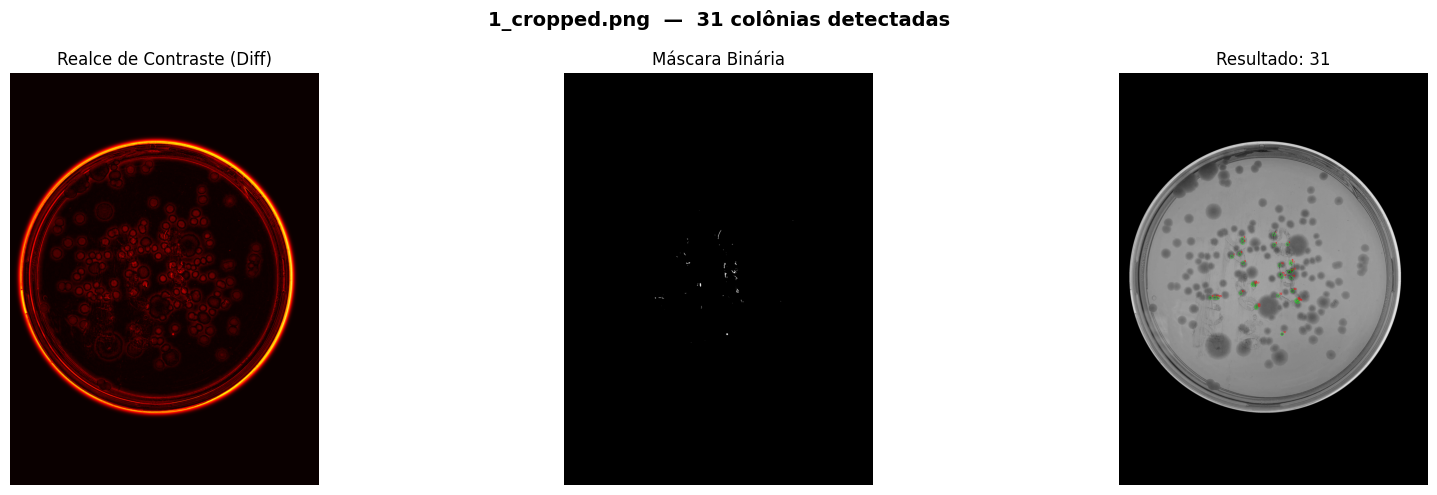

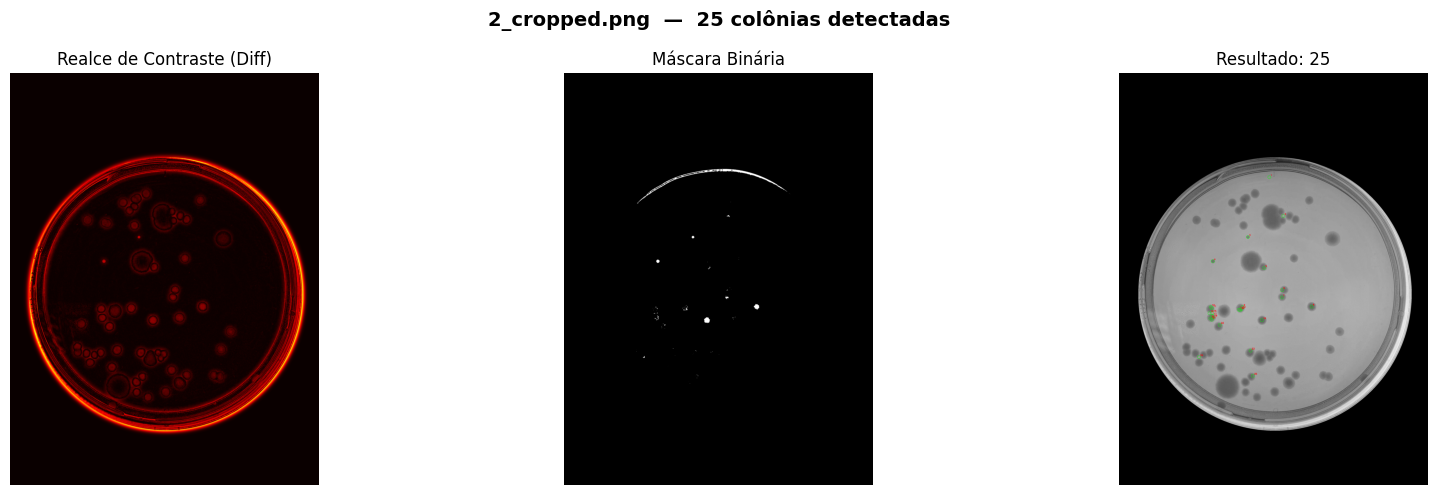

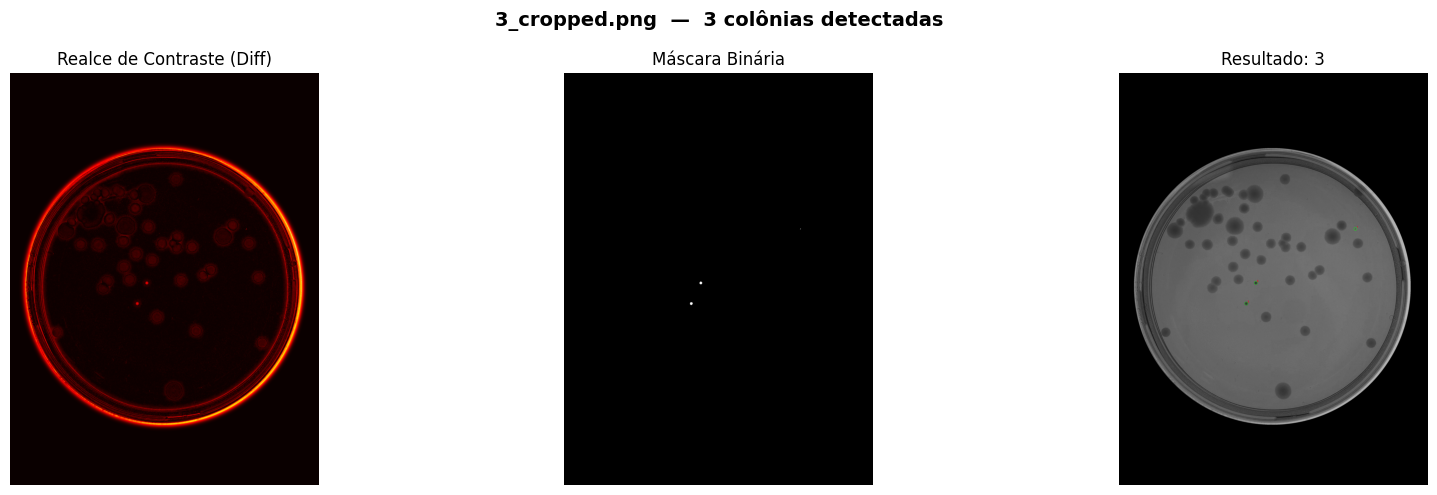

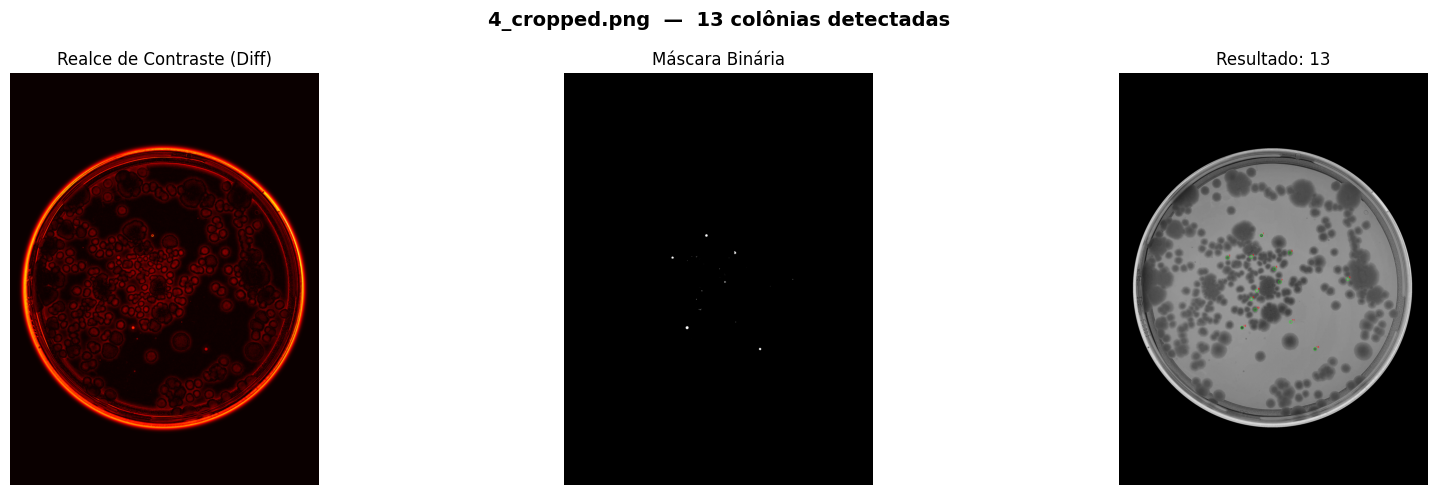

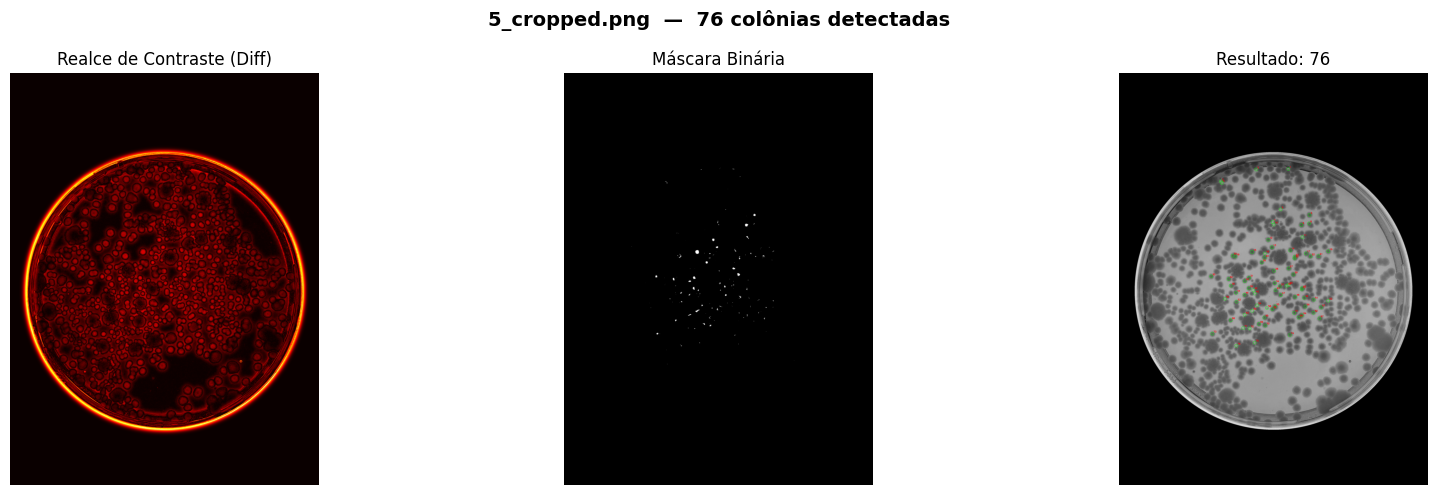

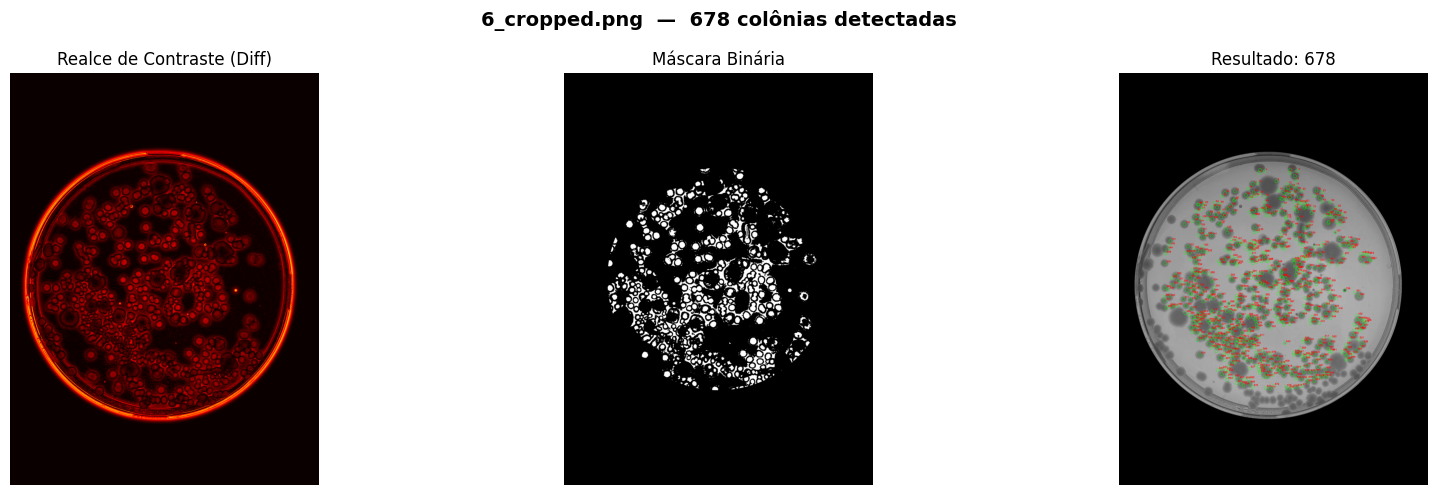

          imagem  colonias
1  1_cropped.png        31
2  2_cropped.png        25
3  3_cropped.png         3
4  4_cropped.png        13
5  5_cropped.png        76
6  6_cropped.png       678

Média de colônias: 137.7
Mínimo: 3 (3_cropped.png)
Máximo: 678 (6_cropped.png)


In [73]:
crop_path = "/Users/laura/Documents/Unicamp/pattern-recognition-petri-dishes/notebooks/laura/data/preprocess/crop_circles_R2"

arquivos_crop = sorted(
    [f for f in os.listdir(crop_path) if f.endswith(".png")],
    key=lambda x: int(x.replace("_cropped", "").replace(".png", ""))
)

resultados = []

for img_name in arquivos_crop:
    img_path = os.path.join(crop_path, img_name)
    img = cv2.imread(img_path)
    if img is None:
        print(f"Erro ao carregar {img_name}")
        continue

    canal_b = img[:, :, 0]
    suave = cv2.medianBlur(canal_b, 5)
    fundo = cv2.GaussianBlur(suave, (151, 151), 0)
    diff = cv2.absdiff(fundo, suave)
    diff = cv2.normalize(diff, None, 0, 255, cv2.NORM_MINMAX)

    _, thresh = cv2.threshold(diff, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    h, w = thresh.shape
    mask_circ = np.zeros((h, w), dtype=np.uint8)
    cv2.circle(mask_circ, (w//2, h//2), int(min(w, h)*0.36), 255, -1)
    f_focada = cv2.bitwise_and(thresh, thresh, mask=mask_circ)

    kernel = np.ones((5, 5), np.uint8)
    f_limpa = cv2.morphologyEx(f_focada, cv2.MORPH_CLOSE, kernel)

    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(f_limpa)

    contagem_real = 0
    viz_final = cv2.cvtColor(canal_b, cv2.COLOR_GRAY2RGB)
    area_minima = 20

    for i in range(1, num_labels):
        area = stats[i, cv2.CC_STAT_AREA]
        if area >= area_minima:
            contagem_real += 1
            cx, cy = centroids[i]
            cv2.circle(viz_final, (int(cx), int(cy)), 15, (0, 255, 0), 2)
            cv2.putText(viz_final, str(contagem_real), (int(cx) + 12, int(cy) - 12),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 0, 0), 2)

    resultados.append({"imagem": img_name, "colonias": contagem_real})

    fig, axs = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f"{img_name}  —  {contagem_real} colônias detectadas", fontsize=14, fontweight='bold')
    axs[0].imshow(diff, cmap='hot');       axs[0].set_title("Realce de Contraste (Diff)"); axs[0].axis('off')
    axs[1].imshow(f_limpa, cmap='gray');   axs[1].set_title("Máscara Binária");            axs[1].axis('off')
    axs[2].imshow(viz_final);              axs[2].set_title(f"Resultado: {contagem_real}"); axs[2].axis('off')
    plt.tight_layout()
    plt.show()

df_resultados = pd.DataFrame(resultados)
df_resultados.index += 1
print(df_resultados.to_string(index=True))
print(f"\nMédia de colônias: {df_resultados['colonias'].mean():.1f}")
print(f"Mínimo: {df_resultados['colonias'].min()} ({df_resultados.loc[df_resultados['colonias'].idxmin(), 'imagem']})")
print(f"Máximo: {df_resultados['colonias'].max()} ({df_resultados.loc[df_resultados['colonias'].idxmax(), 'imagem']})")

In [74]:
import pandas as pd

gabarito = {
    "1_cropped.png": 42,
    "2_cropped.png": 58,
    "3_cropped.png": 44,
    "4_cropped.png": 143,
    "5_cropped.png": 260,
    "6_cropped.png": 170,
}

df = pd.DataFrame(resultados)
df["gabarito"] = df["imagem"].map(gabarito)
df["erro"] = df["colonias"] - df["gabarito"]
df["erro_abs"] = df["erro"].abs()
df["erro_pct"] = (df["erro_abs"] / df["gabarito"] * 100).round(1)
df.index += 1

print(df[["imagem", "gabarito", "colonias", "erro", "erro_pct"]].to_string(index=True))

print(f"\nMédia de erro absoluto: {df['erro_abs'].mean():.1f} colônias")
print(f"Média de erro percentual: {df['erro_pct'].mean():.1f}%")
print(f"Melhor predição: {df.loc[df['erro_abs'].idxmin(), 'imagem']} (erro: {df['erro_abs'].min()})")
print(f"Pior predição:   {df.loc[df['erro_abs'].idxmax(), 'imagem']} (erro: {df['erro_abs'].max()})")

          imagem  gabarito  colonias  erro  erro_pct
1  1_cropped.png        42        31   -11      26.2
2  2_cropped.png        58        25   -33      56.9
3  3_cropped.png        44         3   -41      93.2
4  4_cropped.png       143        13  -130      90.9
5  5_cropped.png       260        76  -184      70.8
6  6_cropped.png       170       678   508     298.8

Média de erro absoluto: 151.2 colônias
Média de erro percentual: 106.1%
Melhor predição: 1_cropped.png (erro: 11)
Pior predição:   6_cropped.png (erro: 508)


## AGAR - high resolution


In [3]:
origem2 = "/Users/laura/Documents/Unicamp/pattern-recognition-petri-dishes/notebooks/laura/data/originals/Img_AGAR/AGAR_high_resolution"
destino2 = "/Users/laura/Documents/Unicamp/pattern-recognition-petri-dishes/notebooks/laura/data/preprocess/jpg2png_AGAR_high/"
output2 = "/Users/laura/Documents/Unicamp/pattern-recognition-petri-dishes/notebooks/laura/data/preprocess/crop_circles_AGAR_high_resolution"

# --- Conversão para PNG renomeado ---
if not os.path.exists(destino2):
    os.makedirs(destino2)

for i, file in enumerate(sorted(os.listdir(origem2)), start=1):
    if file.lower().endswith(".jpg"):
        path_completo = os.path.join(origem2, file)
        print(f"Convertendo: {file}...")
        image = Image.open(path_completo)
        image.save(os.path.join(destino2, f"{i}.png"), format="png")

print("Conversão concluída.")

# --- Hough Circles + recorte ---
if not os.path.exists(output2):
    os.makedirs(output2)

start_time = time.time()

arquivos2 = sorted(
    [f for f in os.listdir(destino2) if f.endswith(".png")],
    key=lambda x: int(os.path.splitext(x)[0])
)

for img_name in arquivos2:
    full_path = os.path.join(destino2, img_name)
    print(f"Processando: {img_name}...")

    img = cv2.imread(full_path)
    if img is None:
        print(f"Erro ao carregar {img_name}")
        continue

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    gray_blurred = cv2.medianBlur(gray, 5)

    circles = cv2.HoughCircles(
        gray_blurred, cv2.HOUGH_GRADIENT,
        dp=1, minDist=100, param1=50, param2=30, minRadius=10, maxRadius=0
    )

    if circles is not None:
        circles = np.uint16(np.around(circles))
        c = circles[0, 0]
        centro_x, centro_y, raio = c[0], c[1], c[2]

        mask = np.zeros_like(gray)
        cv2.circle(mask, (centro_x, centro_y), raio, 255, -1)

        final_img = np.zeros_like(img)
        final_img[mask == 255] = img[mask == 255]

        save_name = f"{os.path.splitext(img_name)[0]}_cropped.png"
        cv2.imwrite(os.path.join(output2, save_name), final_img)
        print(f"   > Salvo: {save_name} (Raio: {raio})")
    else:
        print(f"   > Nenhum círculo detectado em {img_name}.")

print(f"Tempo total: {time.time() - start_time:.2f} segundos")

Convertendo: 11884.jpg...
Convertendo: 12028.jpg...
Convertendo: 510.jpg...
Convertendo: 5206.jpg...
Convertendo: 5312.jpg...
Convertendo: 971.jpg...
Conversão concluída.
Processando: 1.png...
   > Salvo: 1_cropped.png (Raio: 1177)
Processando: 2.png...
   > Salvo: 2_cropped.png (Raio: 1177)
Processando: 3.png...
   > Salvo: 3_cropped.png (Raio: 1454)
Processando: 4.png...
   > Salvo: 4_cropped.png (Raio: 1457)
Processando: 5.png...
   > Salvo: 5_cropped.png (Raio: 1632)
Processando: 6.png...
   > Salvo: 6_cropped.png (Raio: 1426)
Tempo total: 614.67 segundos


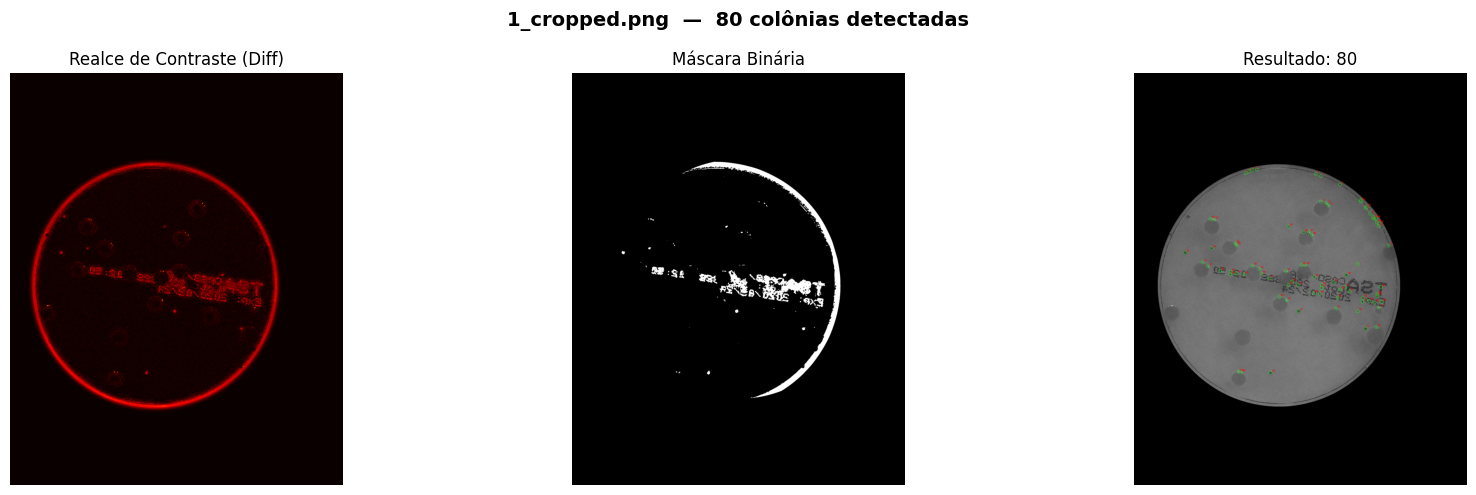

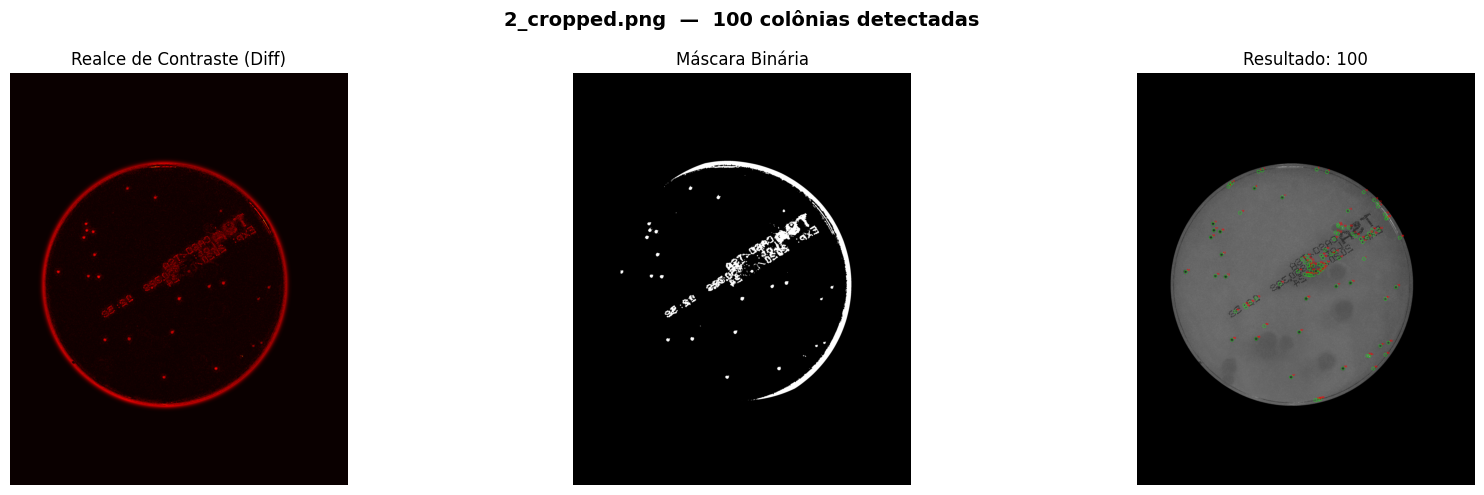

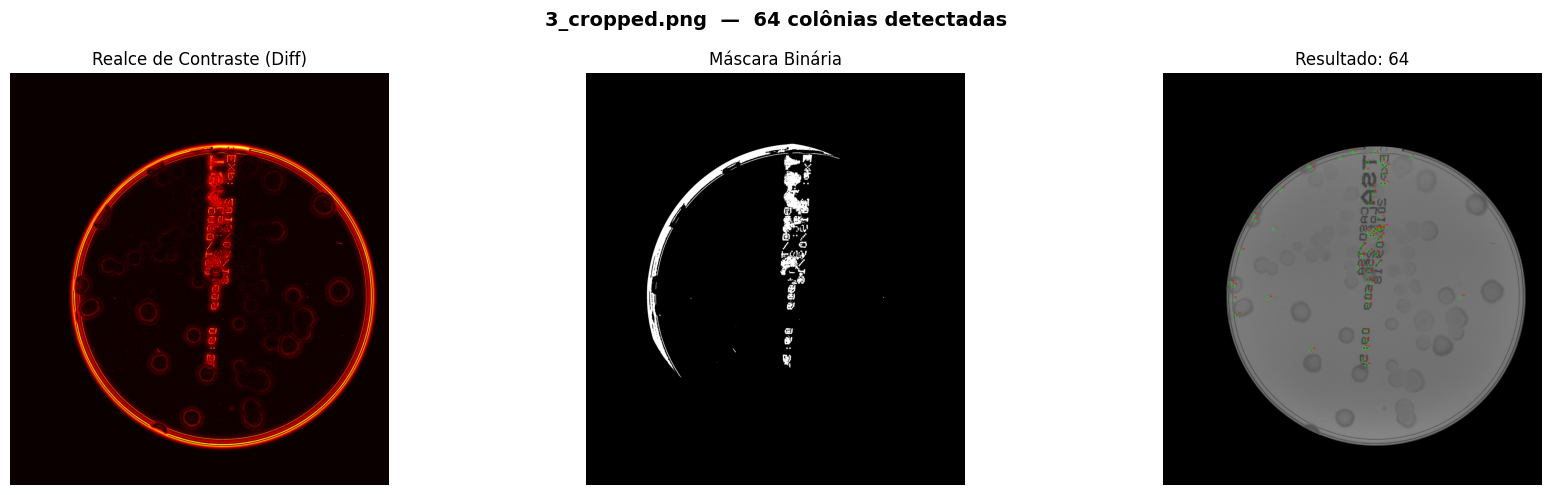

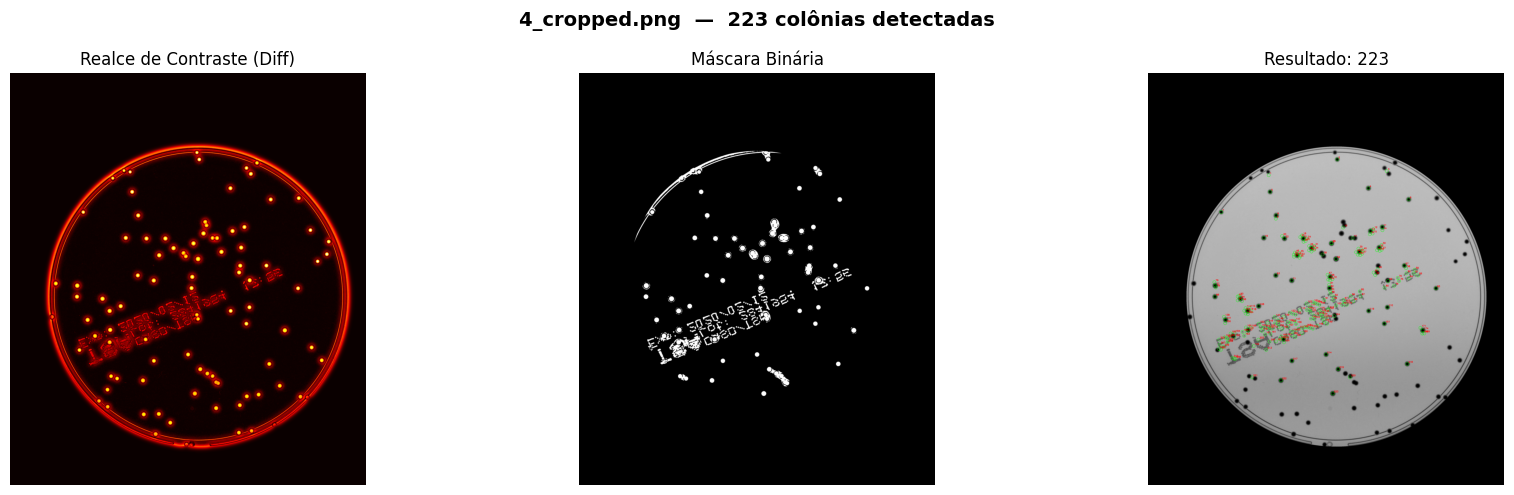

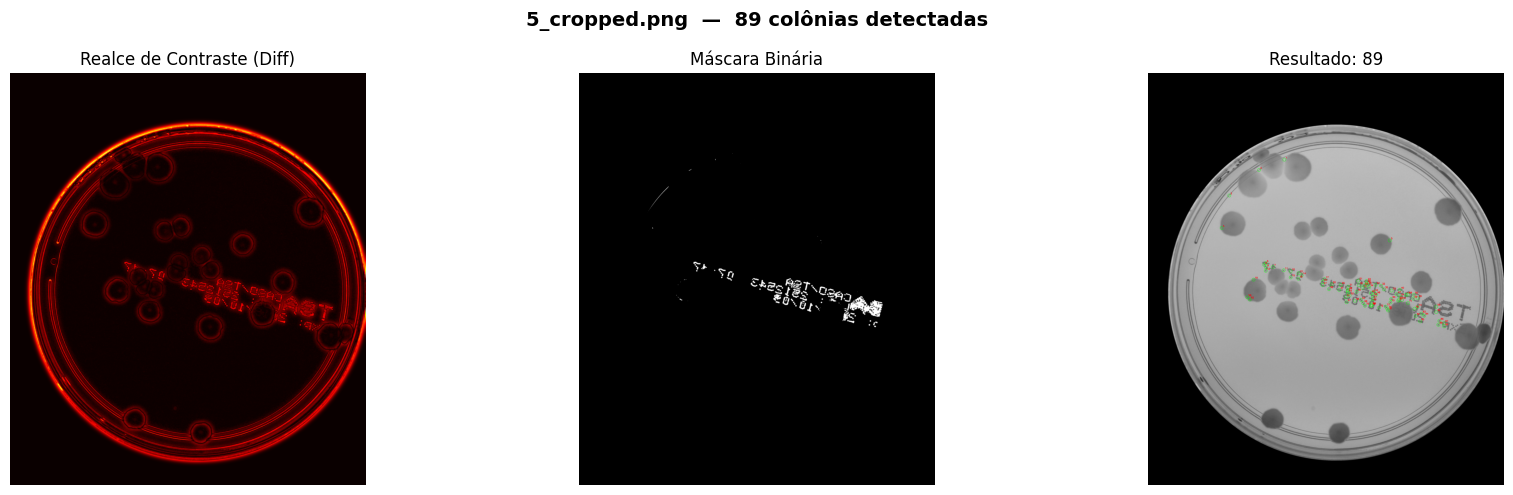

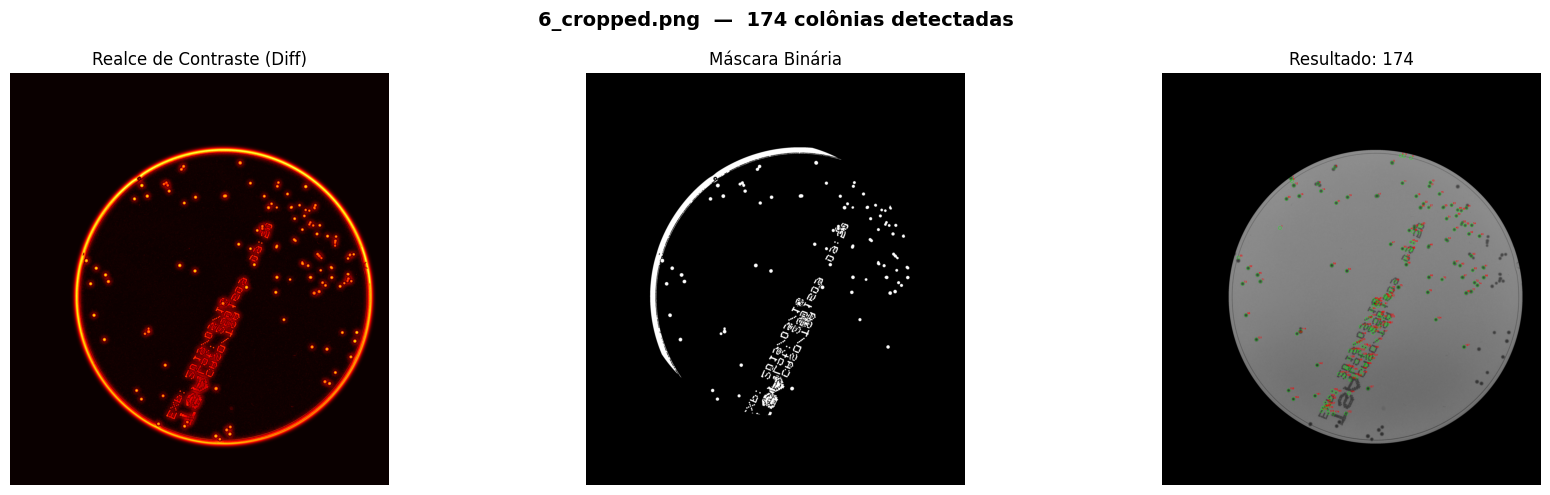

          imagem  colonias
1  1_cropped.png        80
2  2_cropped.png       100
3  3_cropped.png        64
4  4_cropped.png       223
5  5_cropped.png        89
6  6_cropped.png       174

Média de colônias: 121.7
Mínimo: 64 (3_cropped.png)
Máximo: 223 (4_cropped.png)


In [4]:
crop_path = "/Users/laura/Documents/Unicamp/pattern-recognition-petri-dishes/notebooks/laura/data/preprocess/crop_circles_AGAR_high_resolution"

arquivos_crop = sorted(
    [f for f in os.listdir(crop_path) if f.endswith(".png")],
    key=lambda x: int(x.replace("_cropped", "").replace(".png", ""))
)

resultados = []

for img_name in arquivos_crop:
    img_path = os.path.join(crop_path, img_name)
    img = cv2.imread(img_path)
    if img is None:
        print(f"Erro ao carregar {img_name}")
        continue

    canal_b = img[:, :, 0]
    suave = cv2.medianBlur(canal_b, 5)
    fundo = cv2.GaussianBlur(suave, (151, 151), 0)
    diff = cv2.absdiff(fundo, suave)
    diff = cv2.normalize(diff, None, 0, 255, cv2.NORM_MINMAX)

    _, thresh = cv2.threshold(diff, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    h, w = thresh.shape
    mask_circ = np.zeros((h, w), dtype=np.uint8)
    cv2.circle(mask_circ, (w//2, h//2), int(min(w, h)*0.36), 255, -1)
    f_focada = cv2.bitwise_and(thresh, thresh, mask=mask_circ)

    kernel = np.ones((5, 5), np.uint8)
    f_limpa = cv2.morphologyEx(f_focada, cv2.MORPH_CLOSE, kernel)

    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(f_limpa)

    contagem_real = 0
    viz_final = cv2.cvtColor(canal_b, cv2.COLOR_GRAY2RGB)
    area_minima = 20

    for i in range(1, num_labels):
        area = stats[i, cv2.CC_STAT_AREA]
        if area >= area_minima:
            contagem_real += 1
            cx, cy = centroids[i]
            cv2.circle(viz_final, (int(cx), int(cy)), 15, (0, 255, 0), 2)
            cv2.putText(viz_final, str(contagem_real), (int(cx) + 12, int(cy) - 12),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 0, 0), 2)

    resultados.append({"imagem": img_name, "colonias": contagem_real})

    fig, axs = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f"{img_name}  —  {contagem_real} colônias detectadas", fontsize=14, fontweight='bold')
    axs[0].imshow(diff, cmap='hot');       axs[0].set_title("Realce de Contraste (Diff)"); axs[0].axis('off')
    axs[1].imshow(f_limpa, cmap='gray');   axs[1].set_title("Máscara Binária");            axs[1].axis('off')
    axs[2].imshow(viz_final);              axs[2].set_title(f"Resultado: {contagem_real}"); axs[2].axis('off')
    plt.tight_layout()
    plt.show()

df_resultados = pd.DataFrame(resultados)
df_resultados.index += 1
print(df_resultados.to_string(index=True))
print(f"\nMédia de colônias: {df_resultados['colonias'].mean():.1f}")
print(f"Mínimo: {df_resultados['colonias'].min()} ({df_resultados.loc[df_resultados['colonias'].idxmin(), 'imagem']})")
print(f"Máximo: {df_resultados['colonias'].max()} ({df_resultados.loc[df_resultados['colonias'].idxmax(), 'imagem']})")

In [5]:
import pandas as pd

gabarito = {
    "1_cropped.png": 31,
    "2_cropped.png": 41,
    "3_cropped.png": 69,
    "4_cropped.png": 101,
    "5_cropped.png": 25,
    "6_cropped.png": 31,
}

df = pd.DataFrame(resultados)
df["gabarito"] = df["imagem"].map(gabarito)
df["erro"] = df["colonias"] - df["gabarito"]
df["erro_abs"] = df["erro"].abs()
df["erro_pct"] = (df["erro_abs"] / df["gabarito"] * 100).round(1)
df.index += 1

print(df[["imagem", "gabarito", "colonias", "erro", "erro_pct"]].to_string(index=True))

print(f"\nMédia de erro absoluto: {df['erro_abs'].mean():.1f} colônias")
print(f"Média de erro percentual: {df['erro_pct'].mean():.1f}%")
print(f"Melhor predição: {df.loc[df['erro_abs'].idxmin(), 'imagem']} (erro: {df['erro_abs'].min()})")
print(f"Pior predição:   {df.loc[df['erro_abs'].idxmax(), 'imagem']} (erro: {df['erro_abs'].max()})")

          imagem  gabarito  colonias  erro  erro_pct
1  1_cropped.png        31        80    49     158.1
2  2_cropped.png        41       100    59     143.9
3  3_cropped.png        69        64    -5       7.2
4  4_cropped.png       101       223   122     120.8
5  5_cropped.png        25        89    64     256.0
6  6_cropped.png        31       174   143     461.3

Média de erro absoluto: 73.7 colônias
Média de erro percentual: 191.2%
Melhor predição: 3_cropped.png (erro: 5)
Pior predição:   6_cropped.png (erro: 143)


# AGAR - low resolution

In [6]:
origem2 = "/Users/laura/Documents/Unicamp/pattern-recognition-petri-dishes/notebooks/laura/data/originals/Img_AGAR/AGAR_low_resolution"
destino2 = "/Users/laura/Documents/Unicamp/pattern-recognition-petri-dishes/notebooks/laura/data/preprocess/jpg2png_AGAR_low/"
output2 = "/Users/laura/Documents/Unicamp/pattern-recognition-petri-dishes/notebooks/laura/data/preprocess/crop_circles_AGAR_low_resolution"

# --- Conversão para PNG renomeado ---
if not os.path.exists(destino2):
    os.makedirs(destino2)

for i, file in enumerate(sorted(os.listdir(origem2)), start=1):
    if file.lower().endswith(".jpg"):
        path_completo = os.path.join(origem2, file)
        print(f"Convertendo: {file}...")
        image = Image.open(path_completo)
        image.save(os.path.join(destino2, f"{i}.png"), format="png")

print("Conversão concluída.")

# --- Hough Circles + recorte ---
if not os.path.exists(output2):
    os.makedirs(output2)

start_time = time.time()

arquivos2 = sorted(
    [f for f in os.listdir(destino2) if f.endswith(".png")],
    key=lambda x: int(os.path.splitext(x)[0])
)

for img_name in arquivos2:
    full_path = os.path.join(destino2, img_name)
    print(f"Processando: {img_name}...")

    img = cv2.imread(full_path)
    if img is None:
        print(f"Erro ao carregar {img_name}")
        continue

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    gray_blurred = cv2.medianBlur(gray, 5)

    circles = cv2.HoughCircles(
        gray_blurred, cv2.HOUGH_GRADIENT,
        dp=1, minDist=100, param1=50, param2=30, minRadius=10, maxRadius=0
    )

    if circles is not None:
        circles = np.uint16(np.around(circles))
        c = circles[0, 0]
        centro_x, centro_y, raio = c[0], c[1], c[2]

        mask = np.zeros_like(gray)
        cv2.circle(mask, (centro_x, centro_y), raio, 255, -1)

        final_img = np.zeros_like(img)
        final_img[mask == 255] = img[mask == 255]

        save_name = f"{os.path.splitext(img_name)[0]}_cropped.png"
        cv2.imwrite(os.path.join(output2, save_name), final_img)
        print(f"   > Salvo: {save_name} (Raio: {raio})")
    else:
        print(f"   > Nenhum círculo detectado em {img_name}.")

print(f"Tempo total: {time.time() - start_time:.2f} segundos")

Convertendo: 13895.jpg...
Convertendo: 14380.jpg...
Convertendo: 14410.jpg...
Convertendo: 14512.jpg...
Convertendo: 14618.jpg...
Convertendo: 14684.jpg...
Conversão concluída.
Processando: 1.png...
   > Salvo: 1_cropped.png (Raio: 951)
Processando: 2.png...
   > Salvo: 2_cropped.png (Raio: 838)
Processando: 3.png...
   > Salvo: 3_cropped.png (Raio: 944)
Processando: 4.png...
   > Salvo: 4_cropped.png (Raio: 796)
Processando: 5.png...
   > Salvo: 5_cropped.png (Raio: 950)
Processando: 6.png...
   > Salvo: 6_cropped.png (Raio: 832)
Tempo total: 182.74 segundos


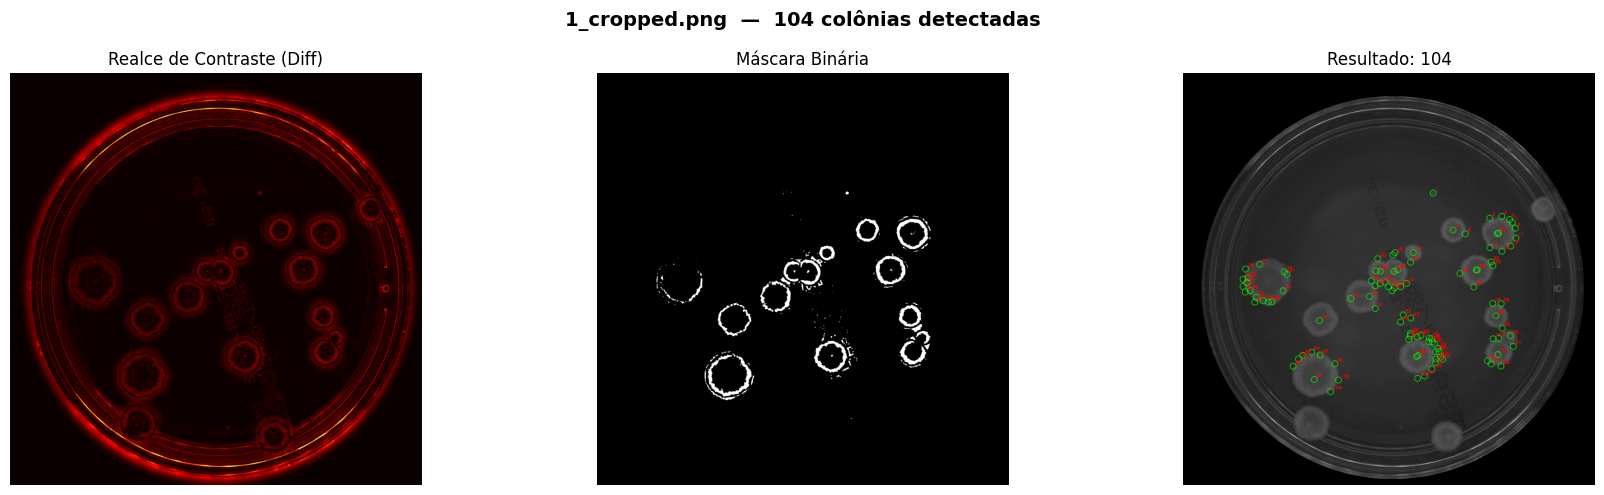

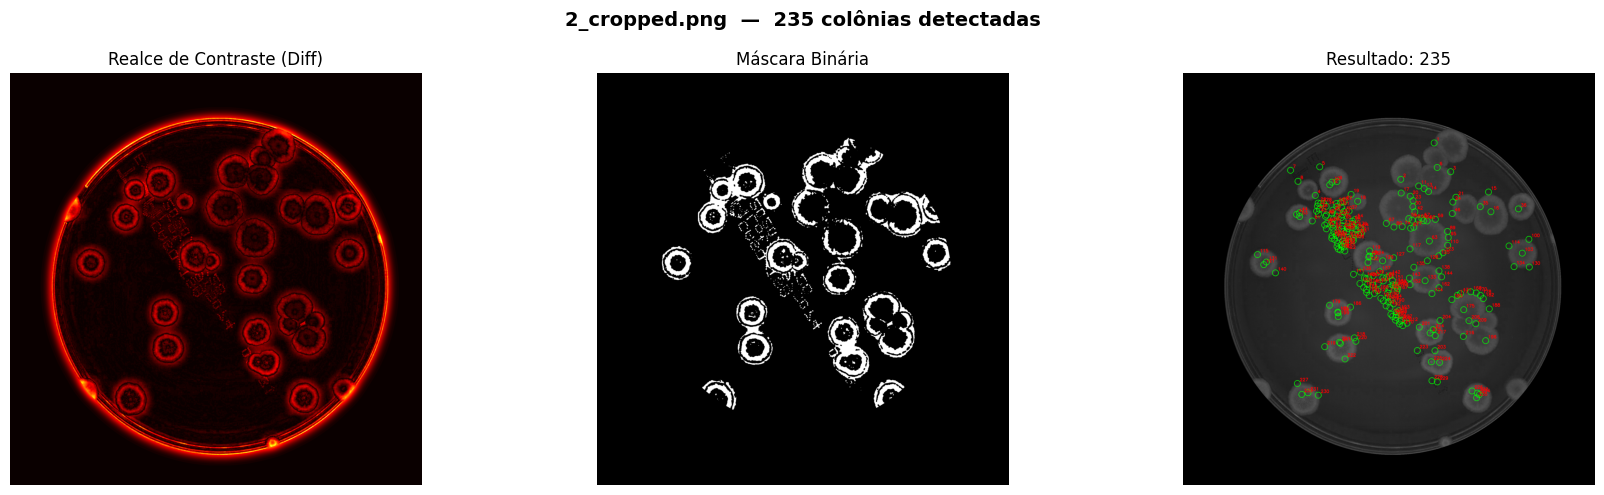

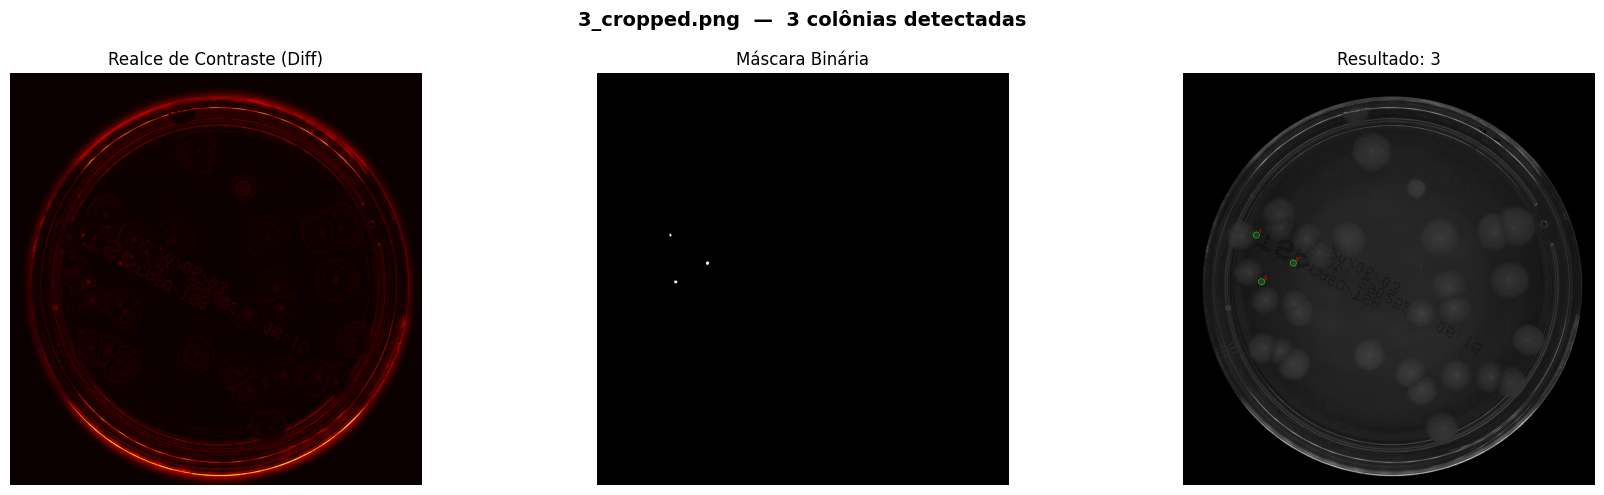

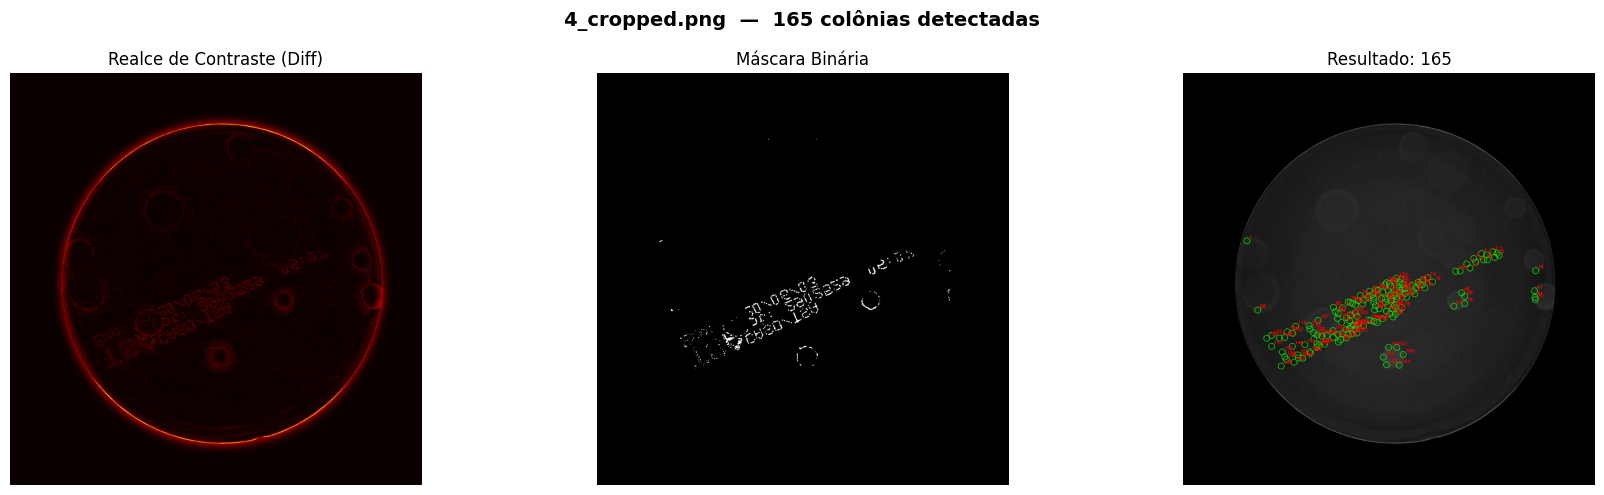

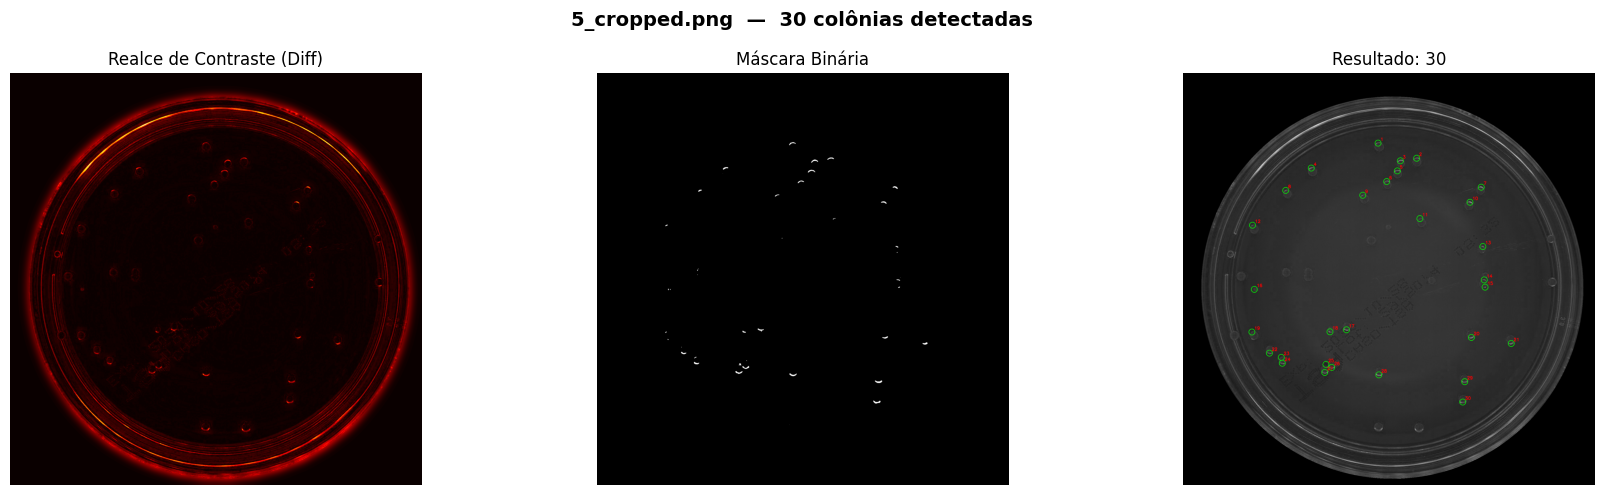

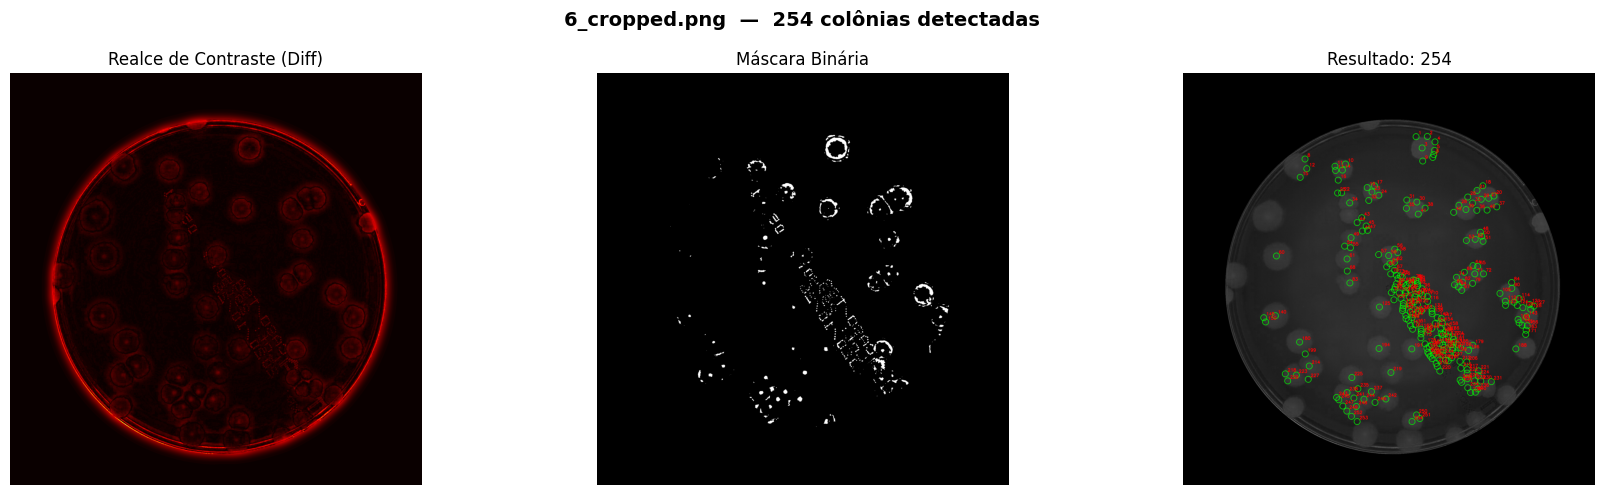

          imagem  colonias
1  1_cropped.png       104
2  2_cropped.png       235
3  3_cropped.png         3
4  4_cropped.png       165
5  5_cropped.png        30
6  6_cropped.png       254

Média de colônias: 131.8
Mínimo: 3 (3_cropped.png)
Máximo: 254 (6_cropped.png)


In [7]:
crop_path = "/Users/laura/Documents/Unicamp/pattern-recognition-petri-dishes/notebooks/laura/data/preprocess/crop_circles_AGAR_low_resolution"

arquivos_crop = sorted(
    [f for f in os.listdir(crop_path) if f.endswith(".png")],
    key=lambda x: int(x.replace("_cropped", "").replace(".png", ""))
)

resultados = []

for img_name in arquivos_crop:
    img_path = os.path.join(crop_path, img_name)
    img = cv2.imread(img_path)
    if img is None:
        print(f"Erro ao carregar {img_name}")
        continue

    canal_b = img[:, :, 0]
    suave = cv2.medianBlur(canal_b, 5)
    fundo = cv2.GaussianBlur(suave, (151, 151), 0)
    diff = cv2.absdiff(fundo, suave)
    diff = cv2.normalize(diff, None, 0, 255, cv2.NORM_MINMAX)

    _, thresh = cv2.threshold(diff, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    h, w = thresh.shape
    mask_circ = np.zeros((h, w), dtype=np.uint8)
    cv2.circle(mask_circ, (w//2, h//2), int(min(w, h)*0.36), 255, -1)
    f_focada = cv2.bitwise_and(thresh, thresh, mask=mask_circ)

    kernel = np.ones((5, 5), np.uint8)
    f_limpa = cv2.morphologyEx(f_focada, cv2.MORPH_CLOSE, kernel)

    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(f_limpa)

    contagem_real = 0
    viz_final = cv2.cvtColor(canal_b, cv2.COLOR_GRAY2RGB)
    area_minima = 20

    for i in range(1, num_labels):
        area = stats[i, cv2.CC_STAT_AREA]
        if area >= area_minima:
            contagem_real += 1
            cx, cy = centroids[i]
            cv2.circle(viz_final, (int(cx), int(cy)), 15, (0, 255, 0), 2)
            cv2.putText(viz_final, str(contagem_real), (int(cx) + 12, int(cy) - 12),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 0, 0), 2)

    resultados.append({"imagem": img_name, "colonias": contagem_real})

    fig, axs = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f"{img_name}  —  {contagem_real} colônias detectadas", fontsize=14, fontweight='bold')
    axs[0].imshow(diff, cmap='hot');       axs[0].set_title("Realce de Contraste (Diff)"); axs[0].axis('off')
    axs[1].imshow(f_limpa, cmap='gray');   axs[1].set_title("Máscara Binária");            axs[1].axis('off')
    axs[2].imshow(viz_final);              axs[2].set_title(f"Resultado: {contagem_real}"); axs[2].axis('off')
    plt.tight_layout()
    plt.show()

df_resultados = pd.DataFrame(resultados)
df_resultados.index += 1
print(df_resultados.to_string(index=True))
print(f"\nMédia de colônias: {df_resultados['colonias'].mean():.1f}")
print(f"Mínimo: {df_resultados['colonias'].min()} ({df_resultados.loc[df_resultados['colonias'].idxmin(), 'imagem']})")
print(f"Máximo: {df_resultados['colonias'].max()} ({df_resultados.loc[df_resultados['colonias'].idxmax(), 'imagem']})")

In [8]:
import pandas as pd

gabarito = {
    "1_cropped.png": 19,
    "2_cropped.png": 34,
    "3_cropped.png": 37,
    "4_cropped.png": 15,
    "5_cropped.png": 40,
    "6_cropped.png": 55,
}

df = pd.DataFrame(resultados)
df["gabarito"] = df["imagem"].map(gabarito)
df["erro"] = df["colonias"] - df["gabarito"]
df["erro_abs"] = df["erro"].abs()
df["erro_pct"] = (df["erro_abs"] / df["gabarito"] * 100).round(1)
df.index += 1

print(df[["imagem", "gabarito", "colonias", "erro", "erro_pct"]].to_string(index=True))

print(f"\nMédia de erro absoluto: {df['erro_abs'].mean():.1f} colônias")
print(f"Média de erro percentual: {df['erro_pct'].mean():.1f}%")
print(f"Melhor predição: {df.loc[df['erro_abs'].idxmin(), 'imagem']} (erro: {df['erro_abs'].min()})")
print(f"Pior predição:   {df.loc[df['erro_abs'].idxmax(), 'imagem']} (erro: {df['erro_abs'].max()})")

          imagem  gabarito  colonias  erro  erro_pct
1  1_cropped.png        19       104    85     447.4
2  2_cropped.png        34       235   201     591.2
3  3_cropped.png        37         3   -34      91.9
4  4_cropped.png        15       165   150    1000.0
5  5_cropped.png        40        30   -10      25.0
6  6_cropped.png        55       254   199     361.8

Média de erro absoluto: 113.2 colônias
Média de erro percentual: 419.6%
Melhor predição: 5_cropped.png (erro: 10)
Pior predição:   2_cropped.png (erro: 201)
